# V11: Multi-GNN — Optuna HPO · Balanced Threshold · 5-Fold CV · Feature Importance

**Fixes over V7:**
- **Reduced Grade-1 recall**: class-weight penalty softened to `sqrt(ratio)` ≈ 1.18; per-fold G-mean threshold optimisation replaces fixed 0.5
- **AUC fix**: explicit named-column construction (no brittle positional rename); `try/except` guard for single-class folds
- **5-Fold Stratified CV**: Optuna finds best params once per model×pipeline, then `StratifiedKFold(5)` evaluates generalisation — reports mean ± std across folds
- Final model trained on full train+val, threshold = mean(fold thresholds), evaluated on held-out TCGA test + external CGGA

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import random, copy, warnings

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report,
                             precision_score, recall_score, f1_score, accuracy_score)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold

from torch_geometric.data import HeteroData
from torch_geometric.nn import (GATv2Conv, Linear, HGTConv,
                                 RGCNConv, HypergraphConv, ChebConv)

from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer
from sdv.sampling import Condition
from imblearn.over_sampling import SMOTENC
from torch.optim.lr_scheduler import CosineAnnealingLR

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

import os

def set_seed(seed=42):
    """Full determinism:
    - Python / NumPy / PyTorch RNGs
    - cuDNN deterministic algorithms (no non-deterministic scatter ops)
    - PYTHONHASHSEED for dict/set ordering
    NOTE: cudnn.deterministic=True adds ~10-20% training overhead.
    """
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True   # no non-det cuDNN kernels
    torch.backends.cudnn.benchmark     = False  # disable auto-tuner (picks diff algo each run)

set_seed(42)

N_TRIALS   = 30    # Optuna TPE trials per model×pipeline
N_FOLDS    = 5     # stratified CV folds
MAX_EPOCHS = 200
PATIENCE   = 20

/home/nafim/anaconda3/envs/thesis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/nafim/anaconda3/envs/thesis/lib/python3.11/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: libnvToolsExt.so.1: cannot open shared object file: No such file or directory
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/home/nafim/anaconda3/envs/thesis/lib/python3.11/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/nafim/anaconda3/envs/thesis/lib/python3.11/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "


Using device: cuda
GPU: NVIDIA GeForce RTX 3050


## 2. Load Data

In [2]:
tcga_df = pd.read_csv('../../dataset/TCGA_InfoWithGrade.csv')
cgga_df = pd.read_csv('../../dataset/weseq_processed_with_id_and_race_V2.csv')

if 'CGGA_ID' in cgga_df.columns:
    cgga_df = cgga_df.drop(columns='CGGA_ID')

categorical_columns = ['Grade', 'Gender', 'Race']
gene_columns = ['IDH1','TP53','ATRX','PTEN','EGFR','CIC','MUC16','PIK3CA',
                'NF1','PIK3R1','FUBP1','RB1','NOTCH1','BCOR','CSMD3',
                'SMARCA4','GRIN2A','IDH2','FAT4','PDGFRA']
NUM_GENES = len(gene_columns)

print("TCGA:", tcga_df.shape, "  Grade dist:", dict(tcga_df['Grade'].value_counts()))
print("CGGA:", cgga_df.shape, "  Grade dist:", dict(cgga_df['Grade'].value_counts()))

TCGA: (839, 24)   Grade dist: {0: 487, 1: 352}
CGGA: (286, 24)   Grade dist: {0: 184, 1: 102}


## 3. Splits — 20% held-out test; remaining 80% used for HPO + 5-Fold CV

In [3]:
# Hold out 20% as final test set (never seen during HPO or CV)
train_val_df, test_df = train_test_split(
    tcga_df, test_size=0.2, stratify=tcga_df['Grade'], random_state=42)

# Further split train_val for Optuna HPO warmup (val graph used only in HPO phase)
train_df, val_df = train_test_split(
    train_val_df, test_size=0.2, stratify=train_val_df['Grade'], random_state=42)

print(f"Train(HPO)={len(train_df)}  Val(HPO)={len(val_df)}  "
      f"TrainVal(CV)={len(train_val_df)}  Test={len(test_df)}")
print("Train Grade dist:", dict(train_df['Grade'].value_counts()))
print("Test  Grade dist:", dict(test_df['Grade'].value_counts()))

Train(HPO)=536  Val(HPO)=135  TrainVal(CV)=671  Test=168
Train Grade dist: {0: 311, 1: 225}
Test  Grade dist: {0: 98, 1: 70}


## 4. Graph Construction

In [4]:
_PP_CACHE: dict = {}


def construct_bipartite_heterograph(df: pd.DataFrame) -> HeteroData:
    graph = HeteroData()
    scaler    = StandardScaler()
    age_norm  = scaler.fit_transform(df[['Age_at_diagnosis']])
    pat_feats = np.hstack([df[['Gender','Race']].values, age_norm])
    graph['Patient'].x = torch.tensor(pat_feats, dtype=torch.float)
    graph['Patient'].y = torch.tensor(df['Grade'].values, dtype=torch.long)
    graph['Gene'].x    = torch.eye(NUM_GENES, dtype=torch.float)

    src_genes, dst_patients = [], []
    for p_idx, (_, row) in enumerate(df.iterrows()):
        for g_idx, gene in enumerate(gene_columns):
            if int(row[gene]) == 1:
                src_genes.append(g_idx); dst_patients.append(p_idx)

    graph['Gene',    'mutates',    'Patient'].edge_index = torch.tensor([src_genes,    dst_patients], dtype=torch.long)
    graph['Patient', 'mutated_by', 'Gene'   ].edge_index = torch.tensor([dst_patients, src_genes   ], dtype=torch.long)
    return graph


def get_pp_edges(graph: HeteroData, max_pts: int = 30):
    key = id(graph)
    if key in _PP_CACHE:
        return _PP_CACHE[key]
    ei = graph[('Gene','mutates','Patient')].edge_index.cpu()
    gene_ids, pat_ids = ei[0], ei[1]
    n_p = graph['Patient'].x.shape[0]
    all_src, all_dst, all_types = [], [], []
    torch.manual_seed(42)
    for g in range(NUM_GENES):
        mask = (gene_ids == g)
        pts = pat_ids[mask].unique(); n = len(pts)
        if n < 2: continue
        if n > max_pts:
            pts = pts[torch.randperm(n)[:max_pts]]; n = max_pts
        src = pts.repeat_interleave(n); dst = pts.repeat(n)
        valid = (src != dst)
        all_src.append(src[valid]); all_dst.append(dst[valid])
        all_types.append(torch.full((valid.sum(),), g, dtype=torch.long))
    if all_src:
        pp_ei = torch.stack([torch.cat(all_src), torch.cat(all_dst)])
        pp_et = torch.cat(all_types)
    else:
        idx = torch.arange(n_p)
        pp_ei = torch.stack([idx, idx]); pp_et = torch.zeros(n_p, dtype=torch.long)
    _PP_CACHE[key] = (pp_ei, pp_et)
    return pp_ei, pp_et


def to_dev(graph): return graph.to(device)


def clear_pp_cache():
    """Call between CV folds to free stale graph-id entries."""
    _PP_CACHE.clear()

## 5. Build Shared Evaluation Graphs

In [5]:
val_graph  = to_dev(construct_bipartite_heterograph(val_df))
test_graph = to_dev(construct_bipartite_heterograph(test_df))
cgga_graph = to_dev(construct_bipartite_heterograph(cgga_df))

print("Val  graph:", val_graph['Patient'].x.shape[0], "patients")
print("Test graph:", test_graph['Patient'].x.shape[0], "patients")
print("CGGA graph:", cgga_graph['Patient'].x.shape[0], "patients")

Val  graph: 135 patients
Test graph: 168 patients
CGGA graph: 286 patients


## 6. Model Definitions (7 architectures)

| # | Model | Core idea |
|---|-------|-----------|
| 1 | **HeteroGATv2** | Bidirectional GATv2 on Gene-Patient bipartite graph |
| 2 | **MOGAT** | Dual genomic+clinical paths, soft fusion gate |
| 3 | **HyperTMO** | Genes = hyperedges, patients = nodes |
| 4 | **RGCN** | Patient-patient co-mutation graph, 20 gene-typed relations |
| 5 | **VEGN** | Learned per-edge variant-effect weights |
| 6 | **FastHGTConv** | Heterogeneous Graph Transformer |
| 7 | **SGNN** | Chebyshev spectral filters on patient co-mutation adjacency |

In [6]:
# ── 1. HeteroGATv2 ───────────────────────────────────────────
class HeteroGATv2(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr = dropout
        self.p_lin = Linear(-1, hidden_dim); self.g_lin = Linear(-1, hidden_dim)
        self.g2p = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.p2g = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.p_skip = Linear(hidden_dim, hidden_dim); self.g_skip = Linear(hidden_dim, hidden_dim)
        self.clf = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        ei = graph.edge_index_dict
        hp = F.relu(self.p_lin(graph['Patient'].x))
        hg = F.relu(self.g_lin(graph['Gene'].x))
        hp = self.p_skip(hp) + self.g2p((hg, hp), ei[('Gene','mutates','Patient')])
        hg = self.g_skip(hg) + self.p2g((hp, hg), ei[('Patient','mutated_by','Gene')])
        return self.clf(F.dropout(F.leaky_relu(hp, 0.2), self.dr, training=self.training))

    def get_attn_weights(self, graph):
        ei = graph.edge_index_dict
        hp = F.relu(self.p_lin(graph['Patient'].x))
        hg = F.relu(self.g_lin(graph['Gene'].x))
        _, (eidx, alpha) = self.g2p((hg, hp), ei[('Gene','mutates','Patient')],
                                     return_attention_weights=True)
        return eidx, alpha.detach().mean(dim=-1)


# ── 2. MOGAT ──────────────────────────────────────────────────────
class MOGAT(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr = dropout
        self.pg = Linear(-1, hidden_dim); self.gg = Linear(-1, hidden_dim)
        self.gat = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.pc = Linear(-1, hidden_dim)
        self.mlp = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
                                  nn.Dropout(dropout), nn.Linear(hidden_dim, hidden_dim))
        self.gate = nn.Linear(hidden_dim * 2, 2); self.clf = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        e = graph[('Gene','mutates','Patient')].edge_index
        hpg = F.relu(self.pg(graph['Patient'].x)); hgg = F.relu(self.gg(graph['Gene'].x))
        hpg = F.dropout(F.leaky_relu(self.gat((hgg, hpg), e), 0.2), self.dr, training=self.training)
        hpc = self.mlp(F.relu(self.pc(graph['Patient'].x)))
        g   = torch.softmax(self.gate(torch.cat([hpg, hpc], -1)), dim=-1)
        return self.clf(g[:, :1] * hpg + g[:, 1:] * hpc)


# ── 3. HyperTMO ───────────────────────────────────────────────────
class HyperTMO(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, in_channels=3, **_):
        super().__init__()
        self.dr = dropout
        self.p_lin = nn.Linear(in_channels, hidden_dim)
        self.g_lin = nn.Linear(NUM_GENES, hidden_dim)        # projects hyperedge attrs
        self.hc1 = HypergraphConv(hidden_dim, hidden_dim, use_attention=True,
                                   heads=num_heads, dropout=dropout, concat=False)
        self.hc2 = HypergraphConv(hidden_dim, hidden_dim)
        self.skip = nn.Linear(hidden_dim, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim); self.clf = nn.Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp = graph['Patient'].x; xg = graph['Gene'].x
        ei = graph[('Gene','mutates','Patient')].edge_index
        hei = torch.stack([ei[1], ei[0]], dim=0)   # [patient, gene]
        hp = F.relu(self.p_lin(xp)); hg = F.relu(self.g_lin(xg)); s = self.skip(hp)
        hp = F.relu(self.hc1(hp, hei, hyperedge_attr=hg))
        hp = F.dropout(hp, self.dr, training=self.training)
        hp = self.bn(F.relu(self.hc2(hp, hei) + s))
        return self.clf(F.dropout(hp, self.dr, training=self.training))


# ── 4. RGCN ───────────────────────────────────────────────────────
class RGCNModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2,
                 in_channels=3, num_relations=20, **_):
        super().__init__()
        self.dr = dropout
        self.lin = nn.Linear(in_channels, hidden_dim)
        self.rc1 = RGCNConv(hidden_dim, hidden_dim, num_relations=num_relations)
        self.rc2 = RGCNConv(hidden_dim, hidden_dim, num_relations=num_relations)
        self.skip = nn.Linear(hidden_dim, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim); self.clf = nn.Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp = graph['Patient'].x
        pp_ei, pp_et = get_pp_edges(graph)
        pp_ei = pp_ei.to(xp.device); pp_et = pp_et.to(xp.device)
        h = F.relu(self.lin(xp)); s = self.skip(h)
        h = F.relu(self.rc1(h, pp_ei, pp_et))
        h = F.dropout(h, self.dr, training=self.training)
        h = self.bn(F.relu(self.rc2(h, pp_ei, pp_et) + s))
        return self.clf(F.dropout(h, self.dr, training=self.training))


# ── 5. VEGN ───────────────────────────────────────────────────────
class VEGNModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr = dropout
        self.p_lin = Linear(-1, hidden_dim); self.g_lin = Linear(-1, hidden_dim)
        self.ve = nn.Sequential(nn.Linear(hidden_dim*2, hidden_dim), nn.ReLU(),
                                 nn.Linear(hidden_dim, 1), nn.Sigmoid())
        self.p2g = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.skip = Linear(hidden_dim, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim); self.clf = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp = graph['Patient'].x; xg = graph['Gene'].x
        e_g2p = graph[('Gene','mutates','Patient')].edge_index
        e_p2g = graph[('Patient','mutated_by','Gene')].edge_index
        hp = F.relu(self.p_lin(xp)); hg = F.relu(self.g_lin(xg))
        sg, dp = e_g2p[0], e_g2p[1]
        wt = self.ve(torch.cat([hg[sg], hp[dp]], -1)).squeeze(-1)
        msg = hg[sg] * wt.unsqueeze(-1)
        agg = torch.zeros_like(hp); agg.scatter_add_(0, dp.unsqueeze(-1).expand_as(msg), msg)
        deg = torch.zeros(hp.shape[0], device=hp.device)
        deg.scatter_add_(0, dp, wt); deg = deg.clamp(min=1)
        agg = agg / deg.unsqueeze(-1)
        _ = self.p2g((hp, hg), e_p2g)
        hp2 = self.bn(F.leaky_relu(self.skip(hp) + agg, 0.2))
        return self.clf(F.dropout(hp2, self.dr, training=self.training))


# ── 6. FastHGTConv ────────────────────────────────────────────────
_HGT_META = (['Patient','Gene'],
              [('Gene','mutates','Patient'),('Patient','mutated_by','Gene')])

class FastHGTModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr = dropout
        self.p_lin = Linear(-1, hidden_dim); self.g_lin = Linear(-1, hidden_dim)
        self.hgt1 = HGTConv(hidden_dim, hidden_dim, metadata=_HGT_META, heads=num_heads)
        self.hgt2 = HGTConv(hidden_dim, hidden_dim, metadata=_HGT_META, heads=num_heads)
        self.skip = Linear(hidden_dim, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim); self.clf = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xd = {'Patient': F.relu(self.p_lin(graph['Patient'].x)),
              'Gene':    F.relu(self.g_lin(graph['Gene'].x))}
        sp = self.skip(xd['Patient']); ei = graph.edge_index_dict
        xd = {k: F.dropout(F.relu(v), self.dr, training=self.training)
              for k, v in self.hgt1(xd, ei).items()}
        xd = self.hgt2(xd, ei)
        hp = self.bn(F.relu(xd['Patient'] + sp))
        return self.clf(F.dropout(hp, self.dr, training=self.training))


# ── 7. SGNN ───────────────────────────────────────────────────────
class SGNNModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2,
                 in_channels=3, K=3, **_):
        super().__init__()
        self.dr = dropout
        self.lin = nn.Linear(in_channels, hidden_dim)
        self.c1 = ChebConv(hidden_dim, hidden_dim, K=K)
        self.c2 = ChebConv(hidden_dim, hidden_dim, K=K)
        self.skip = nn.Linear(hidden_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim); self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.clf = nn.Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp = graph['Patient'].x
        pp_ei, _ = get_pp_edges(graph); pp_ei = pp_ei.to(xp.device)
        h = F.relu(self.lin(xp)); s = self.skip(h)
        h = self.bn1(F.relu(self.c1(h, pp_ei)))
        h = F.dropout(h, self.dr, training=self.training)
        h = self.bn2(F.relu(self.c2(h, pp_ei) + s))
        return self.clf(F.dropout(h, self.dr, training=self.training))


# ── Registry ──────────────────────────────────────────────────────
MODEL_REGISTRY = [
    ('HeteroGATv2', HeteroGATv2,  {}),
    ('MOGAT',       MOGAT,        {}),
    ('HyperTMO',    HyperTMO,     {'in_channels': 3}),
    ('RGCN',        RGCNModel,    {'in_channels': 3, 'num_relations': NUM_GENES}),
    ('VEGN',        VEGNModel,    {}),
    ('FastHGTConv', FastHGTModel, {}),
    ('SGNN',        SGNNModel,    {'in_channels': 3}),
]
print(f"Registered {len(MODEL_REGISTRY)} models:", [n for n,_,_ in MODEL_REGISTRY])

Registered 7 models: ['HeteroGATv2', 'MOGAT', 'HyperTMO', 'RGCN', 'VEGN', 'FastHGTConv', 'SGNN']


## 7. Focal Loss + Softened Class Weights

**Fix**: penalty changed from `ratio` (≈1.38) to `sqrt(ratio)` (≈1.18).  
The FocalLoss `gamma=2` already down-weights easy examples; stacking a high class penalty over-corrects and inflates Grade-1 recall. Softening to square-root keeps a mild correction without making the decision boundary too aggressive toward Grade-1.

In [7]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, weight=None):
        super().__init__()
        self.a, self.g, self.w = alpha, gamma, weight
    def forward(self, inp, tgt):
        ce = F.cross_entropy(inp, tgt, weight=self.w, reduction='none')
        return (self.a * (1 - torch.exp(-ce)) ** self.g * ce).mean()

counts  = train_df['Grade'].value_counts()
# ── FIX: soften penalty from ratio → sqrt(ratio) ─────────────────
penalty = float(np.sqrt(counts.max() / counts.min()))   # was counts.max()/counts.min()
cw      = torch.tensor([1.0, penalty], dtype=torch.float).to(device)
criterion = FocalLoss(alpha=1, gamma=2, weight=cw)
print(f"Class weights: [1.0, {penalty:.4f}]  (sqrt-penalty; was {counts.max()/counts.min():.4f})")

Class weights: [1.0, 1.1757]  (sqrt-penalty; was 1.3822)


## 8. Threshold Optimisation + Evaluation Helpers

**Fix**: `find_optimal_threshold()` searches `[0.30, 0.75]` for the threshold maximising **G-mean = √(recall₀ × recall₁)**. G-mean is maximised when both recalls are balanced, so Grade-1 recall can no longer climb arbitrarily high at Grade-0's expense.

**AUC fix**: `compute_metrics()` uses explicit `try/except` around `roc_auc_score` and returns `nan` for degenerate folds rather than crashing.

In [8]:
# ── FIX: G-mean threshold search ─────────────────────────────────
def find_optimal_threshold(probs: np.ndarray, labels: np.ndarray,
                            low: float = 0.30, high: float = 0.75,
                            step: float = 0.01) -> float:
    """Return the decision threshold in [low, high] that maximises
    G-mean = sqrt(sensitivity_0 * sensitivity_1).
    Falls back to 0.5 if no positive G-mean is found."""
    best_th, best_gm = 0.5, -1.0
    for th in np.arange(low, high + step * 0.5, step):
        preds = (probs >= th).astype(int)
        r1 = recall_score(labels, preds, pos_label=1, zero_division=0)
        r0 = recall_score(labels, preds, pos_label=0, zero_division=0)
        gm = np.sqrt(r0 * r1)
        if gm > best_gm:
            best_gm = gm; best_th = float(th)
    return best_th


def evaluate_model(model, graph, threshold: float = 0.5):
    """Return (preds, probs, labels) using a calibrated threshold."""
    model.eval()
    with torch.no_grad():
        logits = model(graph)
        probs  = F.softmax(logits, 1)[:, 1].cpu().numpy()
        labels = graph['Patient'].y.cpu().numpy()
    preds = (probs >= threshold).astype(int)
    return preds, probs, labels


def compute_metrics(preds: np.ndarray, probs: np.ndarray,
                     labels: np.ndarray) -> dict:
    """AUC fix: explicit try/except; also report per-class recall."""
    try:
        auc = roc_auc_score(labels, probs)
    except ValueError:
        auc = float('nan')   # single-class fold guard
    return {
        'auc':       auc,
        'accuracy':  accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, zero_division=0),
        'recall':    recall_score(labels, preds, zero_division=0),       # Grade-1 recall
        'recall_0':  recall_score(labels, preds, pos_label=0, zero_division=0),
        'f1':        f1_score(labels, preds, zero_division=0),
    }


# Storage containers
all_results  = []    # final test/CGGA results
cv_results   = []    # per-fold CV results
all_models   = {}    # {(model_name, pipeline): trained model}
all_studies  = {}    # {(model_name, pipeline): optuna study}
all_params   = {}    # {(model_name, pipeline): best_params}
all_thresholds = {}  # {(model_name, pipeline): threshold}
PIPELINES    = ['No Balancing', 'SMOTE', 'CTGAN']

## 9. Unified Training Function

In [9]:
def train_and_evaluate(train_graph, val_graph, params, ModelClass,
                        fixed_kw=None, max_epochs=MAX_EPOCHS, patience=PATIENCE,
                        seed=42):
    """Train model; return (best_val_auc, best_state, history)."""
    set_seed(seed)   # reset RNG before every model init+train for reproducibility
    kw = {'hidden_dim': params['hidden_dim'], 'out_dim': 2,
          'num_heads':  params['num_heads'],  'dropout': params['dropout']}
    if fixed_kw: kw.update(fixed_kw)

    model = ModelClass(**kw).to(device)
    try:
        with torch.no_grad(): _ = model(train_graph)
    except Exception: pass

    opt = torch.optim.AdamW(model.parameters(),
                              lr=params['lr'], weight_decay=params['weight_decay'])
    sch = CosineAnnealingLR(opt, T_max=max_epochs, eta_min=params['lr'] * 0.05)

    best_auc, ctr, best_state, history = 0.0, 0, None, []
    for _ in range(max_epochs):
        model.train(); opt.zero_grad()
        loss = criterion(model(train_graph), train_graph['Patient'].y)
        loss.backward(); opt.step(); sch.step()

        model.eval()
        with torch.no_grad():
            vp  = F.softmax(model(val_graph), 1)[:, 1].cpu().numpy()
            vl  = val_graph['Patient'].y.cpu().numpy()
        try:
            auc = roc_auc_score(vl, vp)
        except ValueError:
            auc = 0.0
        history.append(auc)

        if auc > best_auc:
            best_auc, ctr = auc, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            ctr += 1
            if ctr >= patience: break

    return best_auc, best_state, history

## 10. Optuna HPO (warm-up on train_df / val_df)

In [10]:
def run_optuna(train_graph, val_graph, ModelClass, fixed_kw=None,
               n_trials=N_TRIALS, label=''):
    """Bayesian HPO; return (best_params, best_state, study)."""

    def objective(trial):
        set_seed(42)   # same RNG state for every trial → fair comparison
        params = {
            'hidden_dim':   trial.suggest_categorical('hidden_dim', [16, 32, 64, 128]),
            'num_heads':    trial.suggest_categorical('num_heads',  [2, 4, 8]),
            'dropout':      trial.suggest_float('dropout', 0.05, 0.30, step=0.05),
            'lr':           trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            'weight_decay': trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True),
        }
        auc, _, _ = train_and_evaluate(train_graph, val_graph, params, ModelClass, fixed_kw)
        return auc

    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    bp = study.best_params
    print(f"  [{label}] Best AUC={study.best_value:.4f}  params={bp}")
    _, best_state, _ = train_and_evaluate(train_graph, val_graph, bp, ModelClass, fixed_kw)
    return bp, best_state, study

## 11. 5-Fold Stratified Cross-Validation

Uses the **fixed best params** found by Optuna.  Each fold: augment training portion → build graph → train → find G-mean threshold on val → evaluate.  
Reports mean ± std across folds for AUC, Accuracy, Precision, Recall (Grade-1 & Grade-0), F1, Threshold.

In [11]:
def apply_smote(fold_train_df):
    feat_cols = gene_columns + ['Gender','Race','Age_at_diagnosis']
    cat_idx   = [i for i,c in enumerate(feat_cols)
                  if c in gene_columns or c in ['Gender','Race']]
    sm = SMOTENC(categorical_features=cat_idx, random_state=42, k_neighbors=3)
    Xr, yr = sm.fit_resample(fold_train_df[feat_cols], fold_train_df['Grade'])
    df2 = pd.DataFrame(Xr, columns=feat_cols); df2['Grade'] = yr
    for c in gene_columns: df2[c] = df2[c].round().astype(int)
    return df2


def apply_ctgan(fold_train_df):
    meta = SingleTableMetadata()
    meta.detect_from_dataframe(fold_train_df)
    for col in categorical_columns + gene_columns:
        meta.update_column(column_name=col, sdtype='categorical')
    vc    = fold_train_df['Grade'].value_counts()
    n_gen = int(vc.max() - vc.min())
    if n_gen <= 0:
        return fold_train_df
    syn = CTGANSynthesizer(meta, epochs=100, batch_size=50, verbose=False, cuda=True, pac=10)
    syn._model_kwargs = {**getattr(syn, "_model_kwargs", {})}  # ensure fresh
    torch.manual_seed(42); np.random.seed(42)  # seed before CTGAN fit
    syn.fit(fold_train_df)
    cond  = Condition(num_rows=n_gen, column_values={'Grade': int(vc.idxmin())})
    extra = syn.sample_from_conditions(conditions=[cond])
    return pd.concat([fold_train_df, extra], ignore_index=True)


def run_5fold_cv(train_val_df, best_params, ModelClass, fixed_kw,
                  pipeline_name, model_name):
    """Run StratifiedKFold(5) with fixed best_params.
    Returns DataFrame of per-fold metrics."""
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    fold_records = []

    for fold, (tr_idx, vl_idx) in enumerate(
            skf.split(train_val_df, train_val_df['Grade']), start=1):
        fold_tr = train_val_df.iloc[tr_idx].copy().reset_index(drop=True)
        fold_vl = train_val_df.iloc[vl_idx].copy().reset_index(drop=True)

        set_seed(42)   # reset before each fold so augmentation + training are deterministic
        # Apply augmentation to training portion only
        if pipeline_name == 'SMOTE':
            fold_tr = apply_smote(fold_tr)
        elif pipeline_name == 'CTGAN':
            fold_tr = apply_ctgan(fold_tr)

        clear_pp_cache()    # prevent stale cache entries across folds
        tr_g = to_dev(construct_bipartite_heterograph(fold_tr))
        vl_g = to_dev(construct_bipartite_heterograph(fold_vl))

        _, state, _ = train_and_evaluate(tr_g, vl_g, best_params, ModelClass, fixed_kw)

        # Build model for this fold
        kw = {'hidden_dim': best_params['hidden_dim'], 'out_dim': 2,
              'num_heads':  best_params['num_heads'],  'dropout': best_params['dropout']}
        kw.update(fixed_kw)
        fold_model = ModelClass(**kw).to(device)
        try:
            with torch.no_grad(): _ = fold_model(tr_g)
        except: pass
        fold_model.load_state_dict(state)

        # ── FIX: calibrated threshold per fold ────────────────────
        _, probs_v, labels_v = evaluate_model(fold_model, vl_g, threshold=0.5)
        th = find_optimal_threshold(probs_v, labels_v)
        preds_v = (probs_v >= th).astype(int)

        m = compute_metrics(preds_v, probs_v, labels_v)
        m.update({'fold': fold, 'threshold': th,
                  'Model': model_name, 'Pipeline': pipeline_name})
        fold_records.append(m)
        print(f"    Fold {fold}/5 | AUC={m['auc']:.4f} "
              f"R1={m['recall']:.3f} R0={m['recall_0']:.3f} "
              f"F1={m['f1']:.4f} th={th:.2f}")

    clear_pp_cache()
    return pd.DataFrame(fold_records)

## 12. Pipeline Runner (shared by all 3 pipelines)

In [12]:
def run_pipeline(pipeline_name, train_graph_hpo, augment_fn=None):
    """
    For each model in MODEL_REGISTRY:
      1. Optuna HPO on train_df/val_df (or augmented version)
      2. 5-Fold CV on train_val_df with best params
      3. Final model on full train_val (or augmented), calibrated threshold
      4. Evaluate on TCGA test + CGGA
    """
    print(f"\n{'='*65}")
    print(f"PIPELINE: {pipeline_name}")
    print(f"{'='*65}")

    for mname, MCls, fkw in MODEL_REGISTRY:
        print(f"\n  ── {mname} ──")

        # ── Step 1: Optuna HPO ────────────────────────────────────
        bp, hpo_state, study = run_optuna(
            train_graph_hpo, val_graph, MCls, fkw,
            label=f"{mname}/{pipeline_name}")
        all_studies[(mname, pipeline_name)] = study
        all_params[(mname, pipeline_name)]  = bp

        # ── Step 2: 5-Fold CV ─────────────────────────────────────
        print(f"  5-Fold CV with best params:")
        cv_df = run_5fold_cv(train_val_df, bp, MCls, fkw, pipeline_name, mname)
        cv_results.append(cv_df)
        for col in ['auc','accuracy','precision','recall','recall_0','f1','threshold']:
            if col in cv_df.columns:
                print(f"    {col:12s}: {cv_df[col].mean():.4f} ± {cv_df[col].std():.4f}")

        # ── Step 3: Final model on full train_val ─────────────────
        if augment_fn is not None:
            aug_df = augment_fn(train_val_df.copy())
        else:
            aug_df = train_val_df
        clear_pp_cache()
        full_tr_graph = to_dev(construct_bipartite_heterograph(aug_df))

        _, final_state, _ = train_and_evaluate(full_tr_graph, val_graph, bp, MCls, fkw)

        kw = {'hidden_dim': bp['hidden_dim'], 'out_dim': 2,
              'num_heads':  bp['num_heads'],  'dropout': bp['dropout']}
        kw.update(fkw)
        final_model = MCls(**kw).to(device)
        try:
            with torch.no_grad(): _ = final_model(full_tr_graph)
        except: pass
        final_model.load_state_dict(final_state)

        # Threshold = mean of CV fold thresholds
        th = float(cv_df['threshold'].mean())
        all_thresholds[(mname, pipeline_name)] = th
        print(f"  Final threshold (mean of CV folds) = {th:.3f}")

        # ── Step 4: Evaluate on test / CGGA ───────────────────────
        pdt, pbt, lbt = evaluate_model(final_model, test_graph,  threshold=th)
        pdc, pbc, lbc = evaluate_model(final_model, cgga_graph,  threshold=th)
        mt = compute_metrics(pdt, pbt, lbt)
        mc_ = compute_metrics(pdc, pbc, lbc)
        print(f"  TCGA-Test  AUC={mt['auc']:.4f} R1={mt['recall']:.3f} R0={mt['recall_0']:.3f} F1={mt['f1']:.4f}")
        print(f"  CGGA       AUC={mc_['auc']:.4f} R1={mc_['recall']:.3f} R0={mc_['recall_0']:.3f} F1={mc_['f1']:.4f}")

        for ds, m, p, l in [('TCGA Test', mt, pbt, lbt), ('CGGA', mc_, pbc, lbc)]:
            rec = {'Model': mname, 'Pipeline': pipeline_name, 'Dataset': ds,
                   'threshold': th, 'probs': p, 'labels': l}
            rec.update(m)
            all_results.append(rec)
        all_models[(mname, pipeline_name)] = final_model
        clear_pp_cache()

    print(f"\n[{pipeline_name}] Done.")

## 13. Pipeline A — No Balancing

In [13]:
train_nb_graph = to_dev(construct_bipartite_heterograph(train_df))
run_pipeline('No Balancing', train_graph_hpo=train_nb_graph, augment_fn=None)


PIPELINE: No Balancing

  ── HeteroGATv2 ──


Best trial: 21. Best value: 0.932299: 100%|██████████| 30/30 [00:23<00:00,  1.26it/s]


  [HeteroGATv2/No Balancing] Best AUC=0.9323  params={'hidden_dim': 16, 'num_heads': 8, 'dropout': 0.25, 'lr': 0.003368951740328576, 'weight_decay': 0.00046278317037314027}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9262 R1=0.930 R0=0.885 F1=0.8908 th=0.44
    Fold 2/5 | AUC=0.9313 R1=0.893 R0=0.897 F1=0.8772 th=0.50
    Fold 3/5 | AUC=0.9002 R1=0.857 R0=0.872 F1=0.8421 th=0.54
    Fold 4/5 | AUC=0.9487 R1=0.911 R0=0.885 F1=0.8793 th=0.55
    Fold 5/5 | AUC=0.9285 R1=0.947 R0=0.818 F1=0.8640 th=0.50
    auc         : 0.9270 ± 0.0174
    accuracy    : 0.8867 ± 0.0164
    precision   : 0.8377 ± 0.0276
    recall      : 0.9076 ± 0.0348
    recall_0    : 0.8713 ± 0.0311
    f1          : 0.8707 ± 0.0186
    threshold   : 0.5060 ± 0.0434
  Final threshold (mean of CV folds) = 0.506
  TCGA-Test  AUC=0.9235 R1=0.843 R0=0.857 F1=0.8252
  CGGA       AUC=0.7587 R1=0.794 R0=0.625 F1=0.6429

  ── MOGAT ──


Best trial: 23. Best value: 0.943545: 100%|██████████| 30/30 [00:19<00:00,  1.54it/s]


  [MOGAT/No Balancing] Best AUC=0.9435  params={'hidden_dim': 64, 'num_heads': 2, 'dropout': 0.25, 'lr': 0.003171736588373924, 'weight_decay': 5.789908901337073e-05}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9220 R1=0.930 R0=0.872 F1=0.8833 th=0.43
    Fold 2/5 | AUC=0.9148 R1=0.875 R0=0.897 F1=0.8673 th=0.52
    Fold 3/5 | AUC=0.8990 R1=0.893 R0=0.833 F1=0.8403 th=0.53
    Fold 4/5 | AUC=0.9460 R1=0.946 R0=0.885 F1=0.8983 th=0.53
    Fold 5/5 | AUC=0.9337 R1=0.947 R0=0.818 F1=0.8640 th=0.42
    auc         : 0.9231 ± 0.0179
    accuracy    : 0.8852 ± 0.0203
    precision   : 0.8287 ± 0.0325
    recall      : 0.9183 ± 0.0328
    recall_0    : 0.8611 ± 0.0339
    f1          : 0.8706 ± 0.0218
    threshold   : 0.4860 ± 0.0559
  Final threshold (mean of CV folds) = 0.486
  TCGA-Test  AUC=0.9245 R1=0.886 R0=0.837 F1=0.8378
  CGGA       AUC=0.7171 R1=0.755 R0=0.560 F1=0.5923

  ── HyperTMO ──


...

  [VEGN/No Balancing] Best AUC=0.9379  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.05, 'lr': 0.006317518842175363, 'weight_decay': 0.00010746401470107669}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9260 R1=0.930 R0=0.872 F1=0.8833 th=0.43
    Fold 2/5 | AUC=0.9272 R1=0.911 R0=0.859 F1=0.8644 th=0.48
    Fold 3/5 | AUC=0.9048 R1=0.893 R0=0.769 F1=0.8065 th=0.40
    Fold 4/5 | AUC=0.9435 R1=0.911 R0=0.885 F1=0.8793 th=0.52
    Fold 5/5 | AUC=0.9216 R1=0.947 R0=0.805 F1=0.8571 th=0.43
    auc         : 0.9246 ± 0.0138
    accuracy    : 0.8718 ± 0.0311
    precision   : 0.8064 ± 0.0474
    recall      : 0.9183 ± 0.0209
    recall_0    : 0.8380 ± 0.0489
    f1          : 0.8581 ± 0.0308
    threshold   : 0.4520 ± 0.0476
  Final threshold (mean of CV folds) = 0.452
  TCGA-Test  AUC=0.9140 R1=0.914 R0=0.816 F1=0.8421
  CGGA       AUC=0.7239 R1=0.794 R0=0.533 F1=0.6022

  ── FastHGTConv ──


Best trial: 26. Best value: 0.939271: 100%|██████████| 30/30 [00:47<00:00,  1.59s/it]


  [FastHGTConv/No Balancing] Best AUC=0.9393  params={'hidden_dim': 64, 'num_heads': 2, 'dropout': 0.05, 'lr': 0.006081705094694443, 'weight_decay': 3.272480037010719e-05}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9327 R1=0.930 R0=0.859 F1=0.8760 th=0.47
    Fold 2/5 | AUC=0.9373 R1=0.911 R0=0.885 F1=0.8793 th=0.42
    Fold 3/5 | AUC=0.9135 R1=0.875 R0=0.846 F1=0.8376 th=0.50
    Fold 4/5 | AUC=0.9460 R1=0.929 R0=0.872 F1=0.8814 th=0.51
    Fold 5/5 | AUC=0.9376 R1=0.947 R0=0.831 F1=0.8710 th=0.41
    auc         : 0.9334 ± 0.0121
    accuracy    : 0.8837 ± 0.0155
    precision   : 0.8252 ± 0.0203
    recall      : 0.9183 ± 0.0275
    recall_0    : 0.8585 ± 0.0210
    f1          : 0.8691 ± 0.0180
    threshold   : 0.4620 ± 0.0455
  Final threshold (mean of CV folds) = 0.462
  TCGA-Test  AUC=0.8722 R1=0.829 R0=0.796 F1=0.7838
  CGGA       AUC=0.6875 R1=0.706 R0=0.560 F1=0.5647

  ── SGNN ──


Best trial: 22. Best value: 0.917454: 100%|██████████| 30/30 [00:17<00:00,  1.70it/s]


  [SGNN/No Balancing] Best AUC=0.9175  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.1, 'lr': 0.002314535573949917, 'weight_decay': 0.0004510695255175405}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.8297 R1=0.772 R0=0.782 F1=0.7458 th=0.53
    Fold 2/5 | AUC=0.9174 R1=0.893 R0=0.859 F1=0.8547 th=0.42
    Fold 3/5 | AUC=0.8510 R1=0.786 R0=0.846 F1=0.7857 th=0.60
    Fold 4/5 | AUC=0.8977 R1=0.875 R0=0.821 F1=0.8235 th=0.54
    Fold 5/5 | AUC=0.9077 R1=0.895 R0=0.818 F1=0.8361 th=0.48
    auc         : 0.8807 ± 0.0382
    accuracy    : 0.8332 ± 0.0362
    precision   : 0.7778 ± 0.0355
    recall      : 0.8440 ± 0.0602
    recall_0    : 0.8252 ± 0.0296
    f1          : 0.8092 ± 0.0435
    threshold   : 0.5140 ± 0.0677
  Final threshold (mean of CV folds) = 0.514
  TCGA-Test  AUC=0.8603 R1=0.871 R0=0.714 F1=0.7673
  CGGA       AUC=0.6757 R1=0.980 R0=0.114 F1=0.5479

[No Balancing] Done.


## 14. Pipeline B — SMOTE

In [14]:
feat_cols = gene_columns + ['Gender','Race','Age_at_diagnosis']
cat_idx   = [i for i,c in enumerate(feat_cols)
              if c in gene_columns or c in ['Gender','Race']]
smote   = SMOTENC(categorical_features=cat_idx, random_state=42, k_neighbors=3)
Xr, yr  = smote.fit_resample(train_df[feat_cols], train_df['Grade'])
train_smote_df = pd.DataFrame(Xr, columns=feat_cols); train_smote_df['Grade'] = yr
for c in gene_columns: train_smote_df[c] = train_smote_df[c].round().astype(int)
print("SMOTE HPO graph class dist:\n", train_smote_df['Grade'].value_counts())

train_sm_graph = to_dev(construct_bipartite_heterograph(train_smote_df))
run_pipeline('SMOTE', train_graph_hpo=train_sm_graph, augment_fn=apply_smote)

SMOTE HPO graph class dist:
 Grade
0    311
1    311
Name: count, dtype: int64

PIPELINE: SMOTE

  ── HeteroGATv2 ──


Best trial: 25. Best value: 0.931849: 100%|██████████| 30/30 [00:22<00:00,  1.31it/s]


  [HeteroGATv2/SMOTE] Best AUC=0.9318  params={'hidden_dim': 16, 'num_heads': 2, 'dropout': 0.2, 'lr': 0.006721075801867154, 'weight_decay': 0.00033812616524231344}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9283 R1=0.930 R0=0.872 F1=0.8833 th=0.42
    Fold 2/5 | AUC=0.9270 R1=0.893 R0=0.897 F1=0.8772 th=0.48
    Fold 3/5 | AUC=0.9043 R1=0.911 R0=0.808 F1=0.8361 th=0.44
    Fold 4/5 | AUC=0.9453 R1=0.875 R0=0.910 F1=0.8750 th=0.58
    Fold 5/5 | AUC=0.9260 R1=0.947 R0=0.805 F1=0.8571 th=0.47
    auc         : 0.9262 ± 0.0146
    accuracy    : 0.8808 ± 0.0212
    precision   : 0.8267 ± 0.0465
    recall      : 0.9112 ± 0.0287
    recall_0    : 0.8585 ± 0.0495
    f1          : 0.8657 ± 0.0192
    threshold   : 0.4780 ± 0.0618
  Final threshold (mean of CV folds) = 0.478
  TCGA-Test  AUC=0.9061 R1=0.914 R0=0.776 F1=0.8205
  CGGA       AUC=0.7673 R1=0.843 R0=0.505 F1=0.6165

  ── MOGAT ──


Best trial: 29. Best value: 0.932749: 100%|██████████| 30/30 [00:20<00:00,  1.45it/s]


  [MOGAT/SMOTE] Best AUC=0.9327  params={'hidden_dim': 64, 'num_heads': 2, 'dropout': 0.1, 'lr': 0.0012420843047011132, 'weight_decay': 5.795197175939839e-05}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9220 R1=0.930 R0=0.872 F1=0.8833 th=0.46
    Fold 2/5 | AUC=0.9125 R1=0.893 R0=0.846 F1=0.8475 th=0.46
    Fold 3/5 | AUC=0.8993 R1=0.893 R0=0.821 F1=0.8333 th=0.52
    Fold 4/5 | AUC=0.9462 R1=0.929 R0=0.897 F1=0.8966 th=0.57
    Fold 5/5 | AUC=0.9385 R1=0.947 R0=0.818 F1=0.8640 th=0.46
    auc         : 0.9237 ± 0.0190
    accuracy    : 0.8793 ± 0.0240
    precision   : 0.8180 ± 0.0352
    recall      : 0.9183 ± 0.0244
    recall_0    : 0.8508 ± 0.0340
    f1          : 0.8649 ± 0.0257
    threshold   : 0.4940 ± 0.0498
  Final threshold (mean of CV folds) = 0.494
  TCGA-Test  AUC=0.9157 R1=0.914 R0=0.816 F1=0.8421
  CGGA       AUC=0.7277 R1=0.765 R0=0.582 F1=0.6070

  ── HyperTMO ──


...

  [VEGN/SMOTE] Best AUC=0.9334  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.1, 'lr': 0.004798156216545938, 'weight_decay': 0.00017874227348653137}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9222 R1=0.930 R0=0.872 F1=0.8833 th=0.45
    Fold 2/5 | AUC=0.9098 R1=0.821 R0=0.910 F1=0.8440 th=0.55
    Fold 3/5 | AUC=0.9057 R1=0.804 R0=0.872 F1=0.8108 th=0.55
    Fold 4/5 | AUC=0.9515 R1=0.893 R0=0.910 F1=0.8850 th=0.58
    Fold 5/5 | AUC=0.9269 R1=0.965 R0=0.779 F1=0.8527 th=0.47
    auc         : 0.9232 ± 0.0180
    accuracy    : 0.8748 ± 0.0251
    precision   : 0.8337 ± 0.0454
    recall      : 0.8825 ± 0.0691
    recall_0    : 0.8687 ± 0.0536
    f1          : 0.8552 ± 0.0307
    threshold   : 0.5200 ± 0.0566
  Final threshold (mean of CV folds) = 0.520
  TCGA-Test  AUC=0.9188 R1=0.900 R0=0.806 F1=0.8289
  CGGA       AUC=0.7244 R1=0.745 R0=0.571 F1=0.5914

  ── FastHGTConv ──


Best trial: 29. Best value: 0.936122: 100%|██████████| 30/30 [00:50<00:00,  1.69s/it]


  [FastHGTConv/SMOTE] Best AUC=0.9361  params={'hidden_dim': 128, 'num_heads': 4, 'dropout': 0.3, 'lr': 0.0018830043838614242, 'weight_decay': 0.00035518658805520746}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9291 R1=0.930 R0=0.833 F1=0.8618 th=0.42
    Fold 2/5 | AUC=0.9162 R1=0.875 R0=0.923 F1=0.8829 th=0.54
    Fold 3/5 | AUC=0.9121 R1=0.875 R0=0.846 F1=0.8376 th=0.56
    Fold 4/5 | AUC=0.9489 R1=0.929 R0=0.885 F1=0.8889 th=0.54
    Fold 5/5 | AUC=0.9357 R1=0.982 R0=0.805 F1=0.8750 th=0.46
    auc         : 0.9284 ± 0.0149
    accuracy    : 0.8838 ± 0.0193
    precision   : 0.8277 ± 0.0428
    recall      : 0.9182 ± 0.0450
    recall_0    : 0.8585 ± 0.0460
    f1          : 0.8692 ± 0.0204
    threshold   : 0.5040 ± 0.0607
  Final threshold (mean of CV folds) = 0.504
  TCGA-Test  AUC=0.9074 R1=0.886 R0=0.806 F1=0.8212
  CGGA       AUC=0.7671 R1=0.765 R0=0.647 F1=0.6367

  ── SGNN ──


Best trial: 3. Best value: 0.903284: 100%|██████████| 30/30 [00:17<00:00,  1.76it/s]


  [SGNN/SMOTE] Best AUC=0.9033  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.05, 'lr': 0.0023359635026261607, 'weight_decay': 7.591104805282687e-05}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.8273 R1=0.807 R0=0.718 F1=0.7360 th=0.49
    Fold 2/5 | AUC=0.9116 R1=0.839 R0=0.897 F1=0.8468 th=0.52
    Fold 3/5 | AUC=0.8558 R1=0.786 R0=0.846 F1=0.7857 th=0.57
    Fold 4/5 | AUC=0.8965 R1=0.911 R0=0.808 F1=0.8361 th=0.55
    Fold 5/5 | AUC=0.9027 R1=0.825 R0=0.870 F1=0.8246 th=0.59
    auc         : 0.8788 ± 0.0359
    accuracy    : 0.8302 ± 0.0457
    precision   : 0.7828 ± 0.0677
    recall      : 0.8335 ± 0.0476
    recall_0    : 0.8279 ± 0.0697
    f1          : 0.8058 ± 0.0454
    threshold   : 0.5440 ± 0.0397
  Final threshold (mean of CV folds) = 0.544
  TCGA-Test  AUC=0.8414 R1=0.886 R0=0.684 F1=0.7607
  CGGA       AUC=0.6099 R1=0.480 R0=0.560 F1=0.4224

[SMOTE] Done.


## 15. Pipeline C — CTGAN

In [15]:
meta = SingleTableMetadata()
meta.detect_from_dataframe(train_df)
for col in categorical_columns + gene_columns:
    meta.update_column(column_name=col, sdtype='categorical')

cls_c  = train_df['Grade'].value_counts()
maj_c  = cls_c.idxmax(); min_c = cls_c.idxmin()
n_need = int(cls_c[maj_c] - cls_c[min_c])
print(f"Generating {n_need} synthetic minority samples via CTGAN...")

synth = CTGANSynthesizer(meta, epochs=150, batch_size=50, verbose=False, cuda=True)
synth.fit(train_df)
cond   = Condition(num_rows=n_need, column_values={'Grade': int(min_c)})
syn_s  = synth.sample_from_conditions(conditions=[cond])
train_ctgan_df = pd.concat([train_df, syn_s], ignore_index=True)
print("CTGAN HPO graph class dist:\n", train_ctgan_df['Grade'].value_counts())

train_ct_graph = to_dev(construct_bipartite_heterograph(train_ctgan_df))
run_pipeline('CTGAN', train_graph_hpo=train_ct_graph, augment_fn=apply_ctgan)

print("\n✓ All 21 model × pipeline combinations complete.")

Generating 86 synthetic minority samples via CTGAN...


Sampling conditions: 100%|██████████| 86/86 [00:00<00:00, 385.29it/s]


CTGAN HPO graph class dist:
 Grade
0    311
1    311
Name: count, dtype: int64

PIPELINE: CTGAN

  ── HeteroGATv2 ──


Best trial: 27. Best value: 0.939046: 100%|██████████| 30/30 [00:22<00:00,  1.31it/s]


  [HeteroGATv2/CTGAN] Best AUC=0.9390  params={'hidden_dim': 16, 'num_heads': 2, 'dropout': 0.25, 'lr': 0.009973858292566105, 'weight_decay': 0.0001741497497288597}
  5-Fold CV with best params:


...

    Fold 4/5 | AUC=0.8933 R1=0.893 R0=0.808 F1=0.8264 th=0.56


Sampling conditions: 100%|██████████| 87/87 [00:00<00:00, 529.09it/s]


    Fold 5/5 | AUC=0.8856 R1=0.772 R0=0.831 F1=0.7719 th=0.60
    auc         : 0.8763 ± 0.0247
    accuracy    : 0.8167 ± 0.0325
    precision   : 0.7569 ± 0.0257
    recall      : 0.8301 ± 0.0675
    recall_0    : 0.8073 ± 0.0196
    f1          : 0.7912 ± 0.0412
    threshold   : 0.5520 ± 0.0545


Sampling conditions: 100%|██████████| 107/107 [00:00<00:00, 575.66it/s]


  Final threshold (mean of CV folds) = 0.552
  TCGA-Test  AUC=0.8475 R1=0.871 R0=0.714 F1=0.7673
  CGGA       AUC=0.6973 R1=0.951 R0=0.201 F1=0.5607

[CTGAN] Done.

✓ All 21 model × pipeline combinations complete.


## 16. 5-Fold CV Summary Table

In [16]:
cv_all = pd.concat(cv_results, ignore_index=True)

cv_compact = cv_all.groupby(['Model','Pipeline']).apply(
    lambda g: pd.Series({
        'AUC':       f"{g['auc'].mean():.4f} ± {g['auc'].std():.4f}",
        'Recall-1':  f"{g['recall'].mean():.4f} ± {g['recall'].std():.4f}",
        'Recall-0':  f"{g['recall_0'].mean():.4f} ± {g['recall_0'].std():.4f}",
        'F1':        f"{g['f1'].mean():.4f} ± {g['f1'].std():.4f}",
        'Threshold': f"{g['threshold'].mean():.3f} ± {g['threshold'].std():.3f}",
    })
).reset_index()

print("\n5-FOLD CV SUMMARY (mean ± std across 5 folds)")
print("="*90)
print(cv_compact.to_string(index=False))


5-FOLD CV SUMMARY (mean ± std across 5 folds)
      Model     Pipeline             AUC        Recall-1        Recall-0              F1     Threshold
FastHGTConv        CTGAN 0.9204 ± 0.0175 0.9219 ± 0.0240 0.8379 ± 0.0388 0.8599 ± 0.0227 0.504 ± 0.038
FastHGTConv No Balancing 0.9334 ± 0.0121 0.9183 ± 0.0275 0.8585 ± 0.0210 0.8691 ± 0.0180 0.462 ± 0.045
FastHGTConv        SMOTE 0.9284 ± 0.0149 0.9182 ± 0.0450 0.8585 ± 0.0460 0.8692 ± 0.0204 0.504 ± 0.061
HeteroGATv2        CTGAN 0.9242 ± 0.0167 0.9184 ± 0.0242 0.8430 ± 0.0532 0.8611 ± 0.0259 0.530 ± 0.035
HeteroGATv2 No Balancing 0.9270 ± 0.0174 0.9076 ± 0.0348 0.8713 ± 0.0311 0.8707 ± 0.0186 0.506 ± 0.043
HeteroGATv2        SMOTE 0.9262 ± 0.0146 0.9112 ± 0.0287 0.8585 ± 0.0495 0.8657 ± 0.0192 0.478 ± 0.062
   HyperTMO        CTGAN 0.8128 ± 0.0330 0.7767 ± 0.0790 0.7092 ± 0.0759 0.7131 ± 0.0437 0.538 ± 0.015
   HyperTMO No Balancing 0.8195 ± 0.0349 0.7555 ± 0.0372 0.7610 ± 0.0573 0.7253 ± 0.0430 0.524 ± 0.011
   HyperTMO        SMOTE 0

## 17. Final Results Table (TCGA Test + CGGA)

**AUC fix**: columns built explicitly by name — no brittle positional assignment.

In [17]:
# ── Build clean results_df (deduplicated, named columns) ────────
# all_results may have duplicate entries if run_pipeline was called
# multiple times; keep the last entry per (Model, Pipeline, Dataset).
_raw = []
for r in all_results:
    _raw.append({
        'Model':     r['Model'],
        'Pipeline':  r['Pipeline'],
        'Dataset':   r['Dataset'],
        'Threshold': round(r['threshold'], 3),
        'AUC':       round(r['auc'],       4),
        'Accuracy':  round(r['accuracy'],  4),
        'Precision': round(r['precision'], 4),
        'Recall_1':  round(r['recall'],    4),
        'Recall_0':  round(r['recall_0'],  4),
        'F1':        round(r['f1'],        4),
    })

results_df = (pd.DataFrame(_raw)
              .drop_duplicates(subset=['Model','Pipeline','Dataset'], keep='last')
              .reset_index(drop=True))

print("\n" + "="*115)
print("FINAL RESULTS — 7 MODELS × 3 PIPELINES × 2 DATASETS")
print("="*115)
print(results_df.to_string(index=False))

# ── Summary table: best per model (max AUC across pipelines) ─────
print("\n" + "="*115)
print("SUMMARY — BEST PIPELINE PER MODEL (by AUC)")
print("="*115)
for ds in ['TCGA Test', 'CGGA']:
    sub = results_df[results_df.Dataset == ds]
    best = (sub.sort_values('AUC', ascending=False)
               .drop_duplicates('Model')
               [['Model','Pipeline','AUC','Recall_1','Recall_0','F1','Threshold']])
    print(f"\n{ds}:")
    print(best.to_string(index=False))

print("\nTop-5 overall by AUC on TCGA Test:")
print(results_df[results_df.Dataset=='TCGA Test']
      .sort_values('AUC', ascending=False).head(5)
      [['Model','Pipeline','AUC','Recall_1','Recall_0','F1']].to_string(index=False))

print("\nTop-5 overall by AUC on CGGA:")
print(results_df[results_df.Dataset=='CGGA']
      .sort_values('AUC', ascending=False).head(5)
      [['Model','Pipeline','AUC','Recall_1','Recall_0','F1']].to_string(index=False))

# ── Export CSVs ───────────────────────────────────────────────────
results_df.to_csv('V11_results_final.csv', index=False)
print("\n✓ Exported: V11_results_final.csv")

# CV summary CSV (mean ± std per model × pipeline)
cv_all = pd.concat(cv_results, ignore_index=True) if cv_results else pd.DataFrame()
if not cv_all.empty:
    cv_summary = (cv_all.groupby(['Model','Pipeline'])
                  [['auc','accuracy','precision','recall','recall_0','f1','threshold']]
                  .agg(['mean','std'])
                  .round(4))
    # Flatten multi-level columns  e.g. ('auc','mean') -> 'auc_mean'
    cv_summary.columns = ['_'.join(c) for c in cv_summary.columns]
    cv_summary = cv_summary.reset_index()
    cv_summary.to_csv('V11_cv_summary.csv', index=False)
    cv_all.to_csv('V11_cv_folds.csv', index=False)
    print("✓ Exported: V11_cv_summary.csv  (mean±std per model×pipeline)")
    print("✓ Exported: V11_cv_folds.csv    (raw per-fold results)")


FINAL RESULTS — 7 MODELS × 3 PIPELINES × 2 DATASETS
      Model     Pipeline   Dataset  Threshold    AUC  Accuracy  Precision  Recall_1  Recall_0     F1
HeteroGATv2 No Balancing TCGA Test      0.506 0.9235    0.8512     0.8082    0.8429    0.8571 0.8252
HeteroGATv2 No Balancing      CGGA      0.506 0.7587    0.6853     0.5400    0.7941    0.6250 0.6429
      MOGAT No Balancing TCGA Test      0.486 0.9245    0.8571     0.7949    0.8857    0.8367 0.8378
      MOGAT No Balancing      CGGA      0.486 0.7171    0.6294     0.4873    0.7549    0.5598 0.5923
   HyperTMO No Balancing TCGA Test      0.524 0.8117    0.7500     0.7121    0.6714    0.8061 0.6912
   HyperTMO No Balancing      CGGA      0.524 0.7009    0.6538     0.5118    0.6373    0.6630 0.5677
       RGCN No Balancing TCGA Test      0.426 0.8837    0.7619     0.6531    0.9143    0.6531 0.7619
       RGCN No Balancing      CGGA      0.426 0.6985    0.5000     0.4028    0.8333    0.3152 0.5431
       VEGN No Balancing TCGA Test    

## 18. AUC Heatmaps

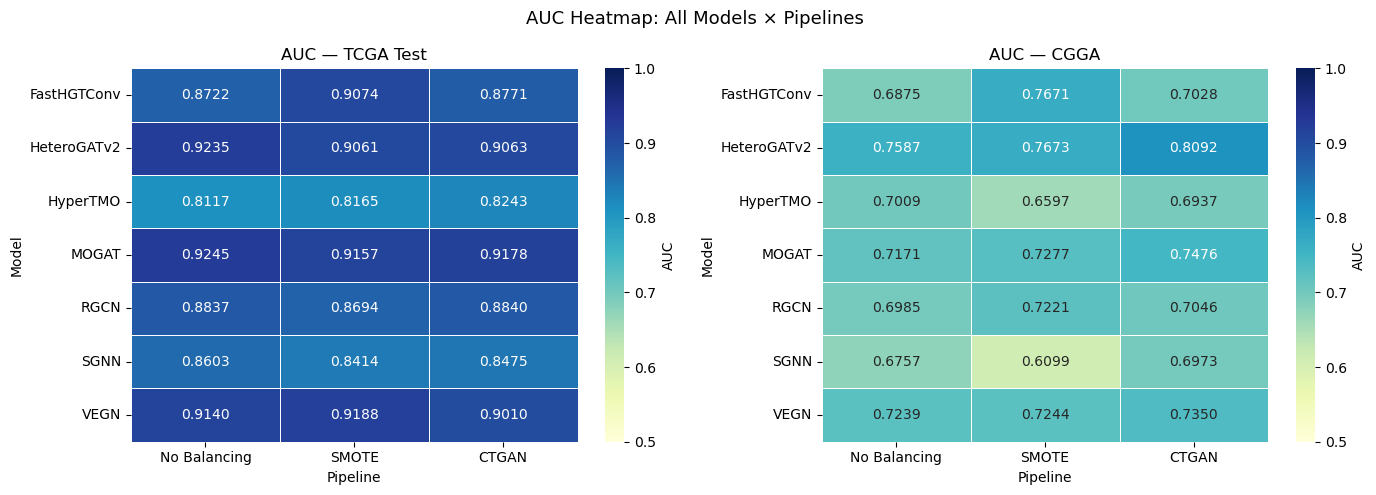

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ds in zip(axes, ['TCGA Test', 'CGGA']):
    # pivot_table with aggfunc='mean' safely handles any duplicate rows
    pivot = (results_df[results_df.Dataset == ds]
             .pivot_table(index='Model', columns='Pipeline',
                          values='AUC', aggfunc='mean')
             .reindex(columns=['No Balancing', 'SMOTE', 'CTGAN']))
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu',
                linewidths=0.5, ax=ax, vmin=0.5, vmax=1.0,
                cbar_kws={'label': 'AUC'})
    ax.set_title(f'AUC — {ds}', fontsize=12)
    ax.set_xlabel('Pipeline'); ax.set_ylabel('Model')
plt.suptitle('AUC Heatmap: All Models × Pipelines', fontsize=13)
plt.tight_layout()
plt.savefig('V11_auc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 19. Recall Heatmaps — Grade-1 and Grade-0 (TCGA Test)

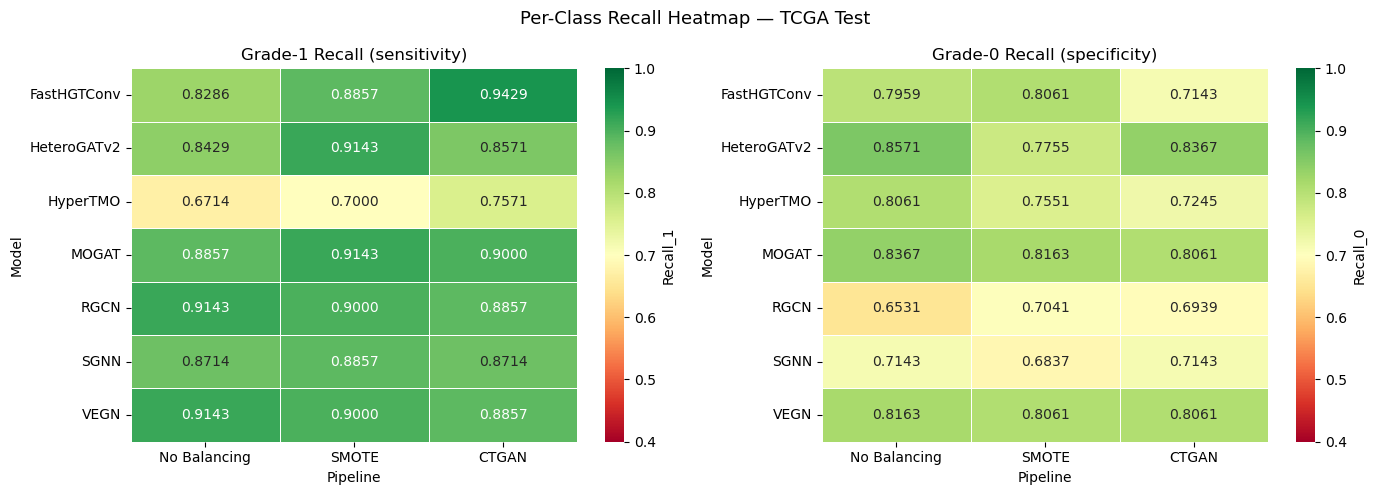

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in [
        (axes[0], 'Recall_1', 'Grade-1 Recall (sensitivity)'),
        (axes[1], 'Recall_0', 'Grade-0 Recall (specificity)')]:
    pivot = (results_df[results_df.Dataset == 'TCGA Test']
             .pivot_table(index='Model', columns='Pipeline',
                          values=col, aggfunc='mean')
             .reindex(columns=['No Balancing', 'SMOTE', 'CTGAN']))
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='RdYlGn',
                linewidths=0.5, ax=ax, vmin=0.4, vmax=1.0,
                cbar_kws={'label': col})
    ax.set_title(title); ax.set_xlabel('Pipeline'); ax.set_ylabel('Model')
plt.suptitle('Per-Class Recall Heatmap — TCGA Test', fontsize=13)
plt.tight_layout()
plt.savefig('V11_recall_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 20. 5-Fold CV Box Plots

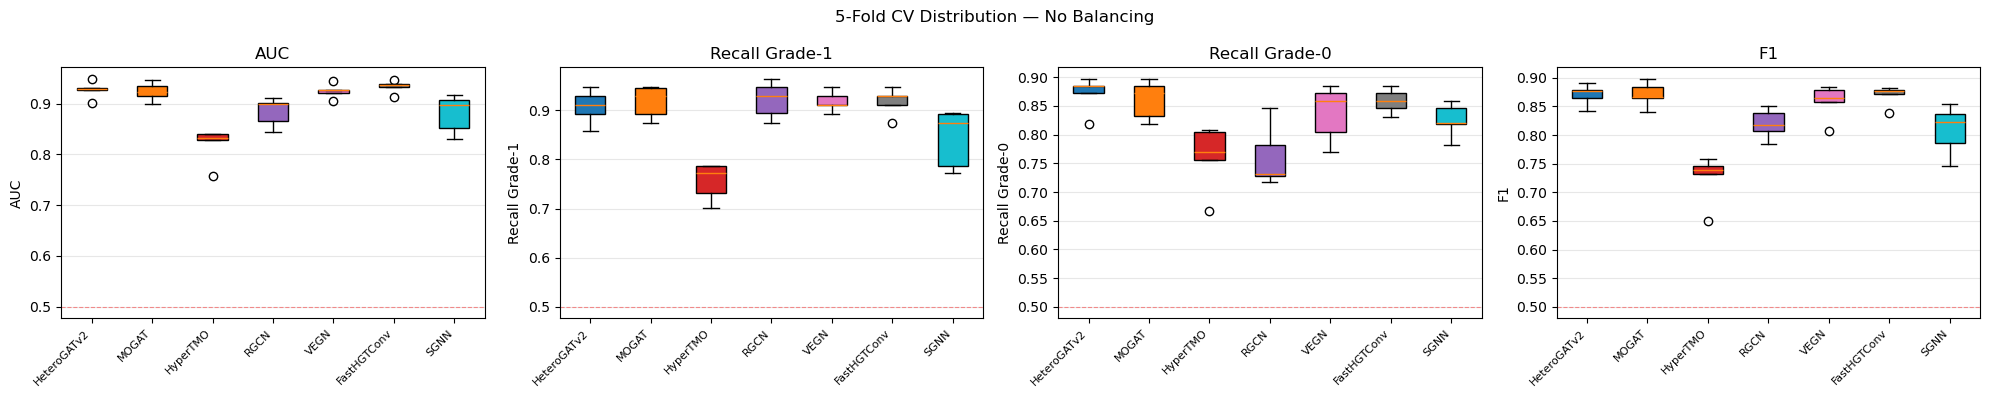

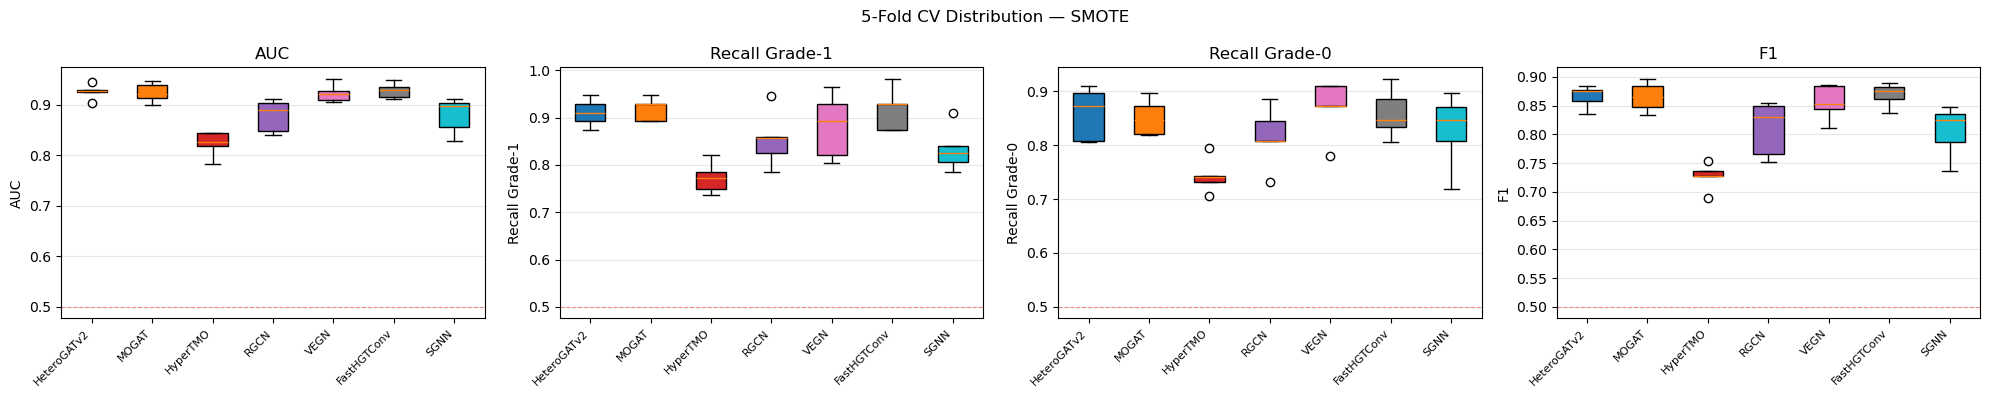

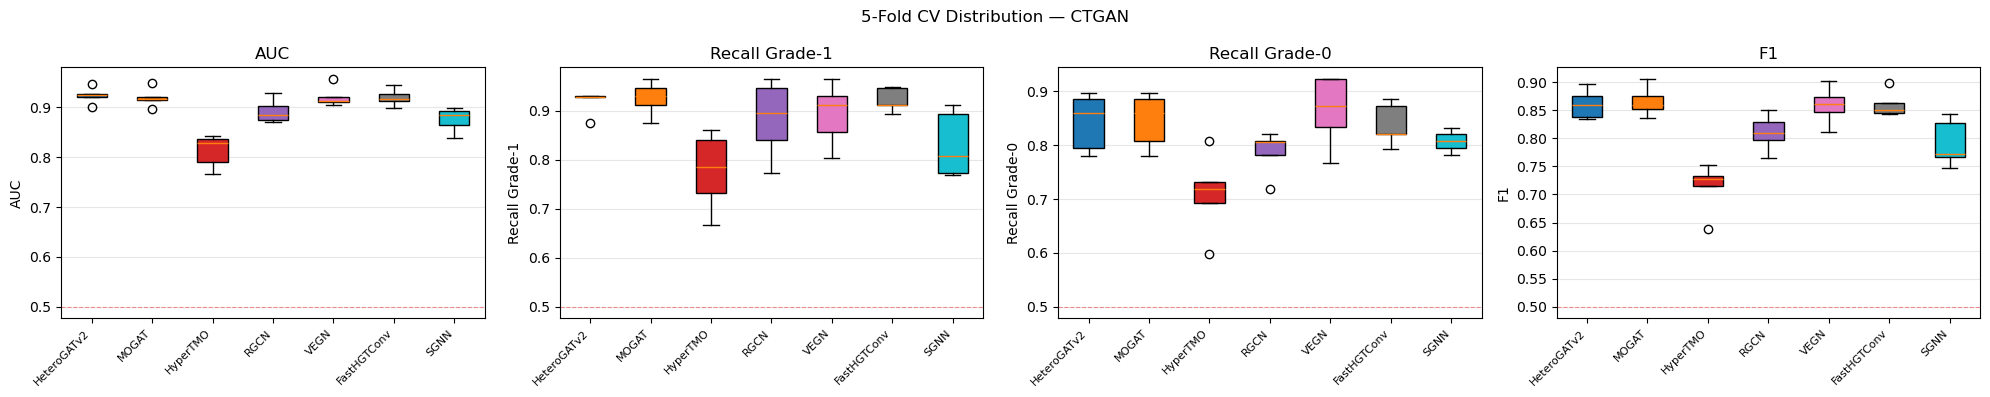

In [20]:
metrics_cv = ['auc', 'recall', 'recall_0', 'f1']
labels_cv  = ['AUC', 'Recall Grade-1', 'Recall Grade-0', 'F1']
model_names = [n for n, _, _ in MODEL_REGISTRY]

for pipe in PIPELINES:
    sub = cv_all[cv_all.Pipeline == pipe]
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    for ax, met, lab in zip(axes, metrics_cv, labels_cv):
        data = [sub[sub.Model == m][met].values for m in model_names]
        bp = ax.boxplot(data, patch_artist=True, notch=False)
        colors = plt.cm.tab10(np.linspace(0, 0.9, len(model_names)))
        for patch, col in zip(bp['boxes'], colors):
            patch.set_facecolor(col)
        ax.set_xticks(range(1, len(model_names)+1))
        ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=8)
        ax.set_ylabel(lab); ax.set_title(lab); ax.grid(axis='y', alpha=0.3)
        ax.axhline(0.5, color='red', ls='--', alpha=0.4, lw=0.8)
    plt.suptitle(f'5-Fold CV Distribution — {pipe}', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'V11_cv_boxplot_{pipe.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 21. ROC Curve Grid

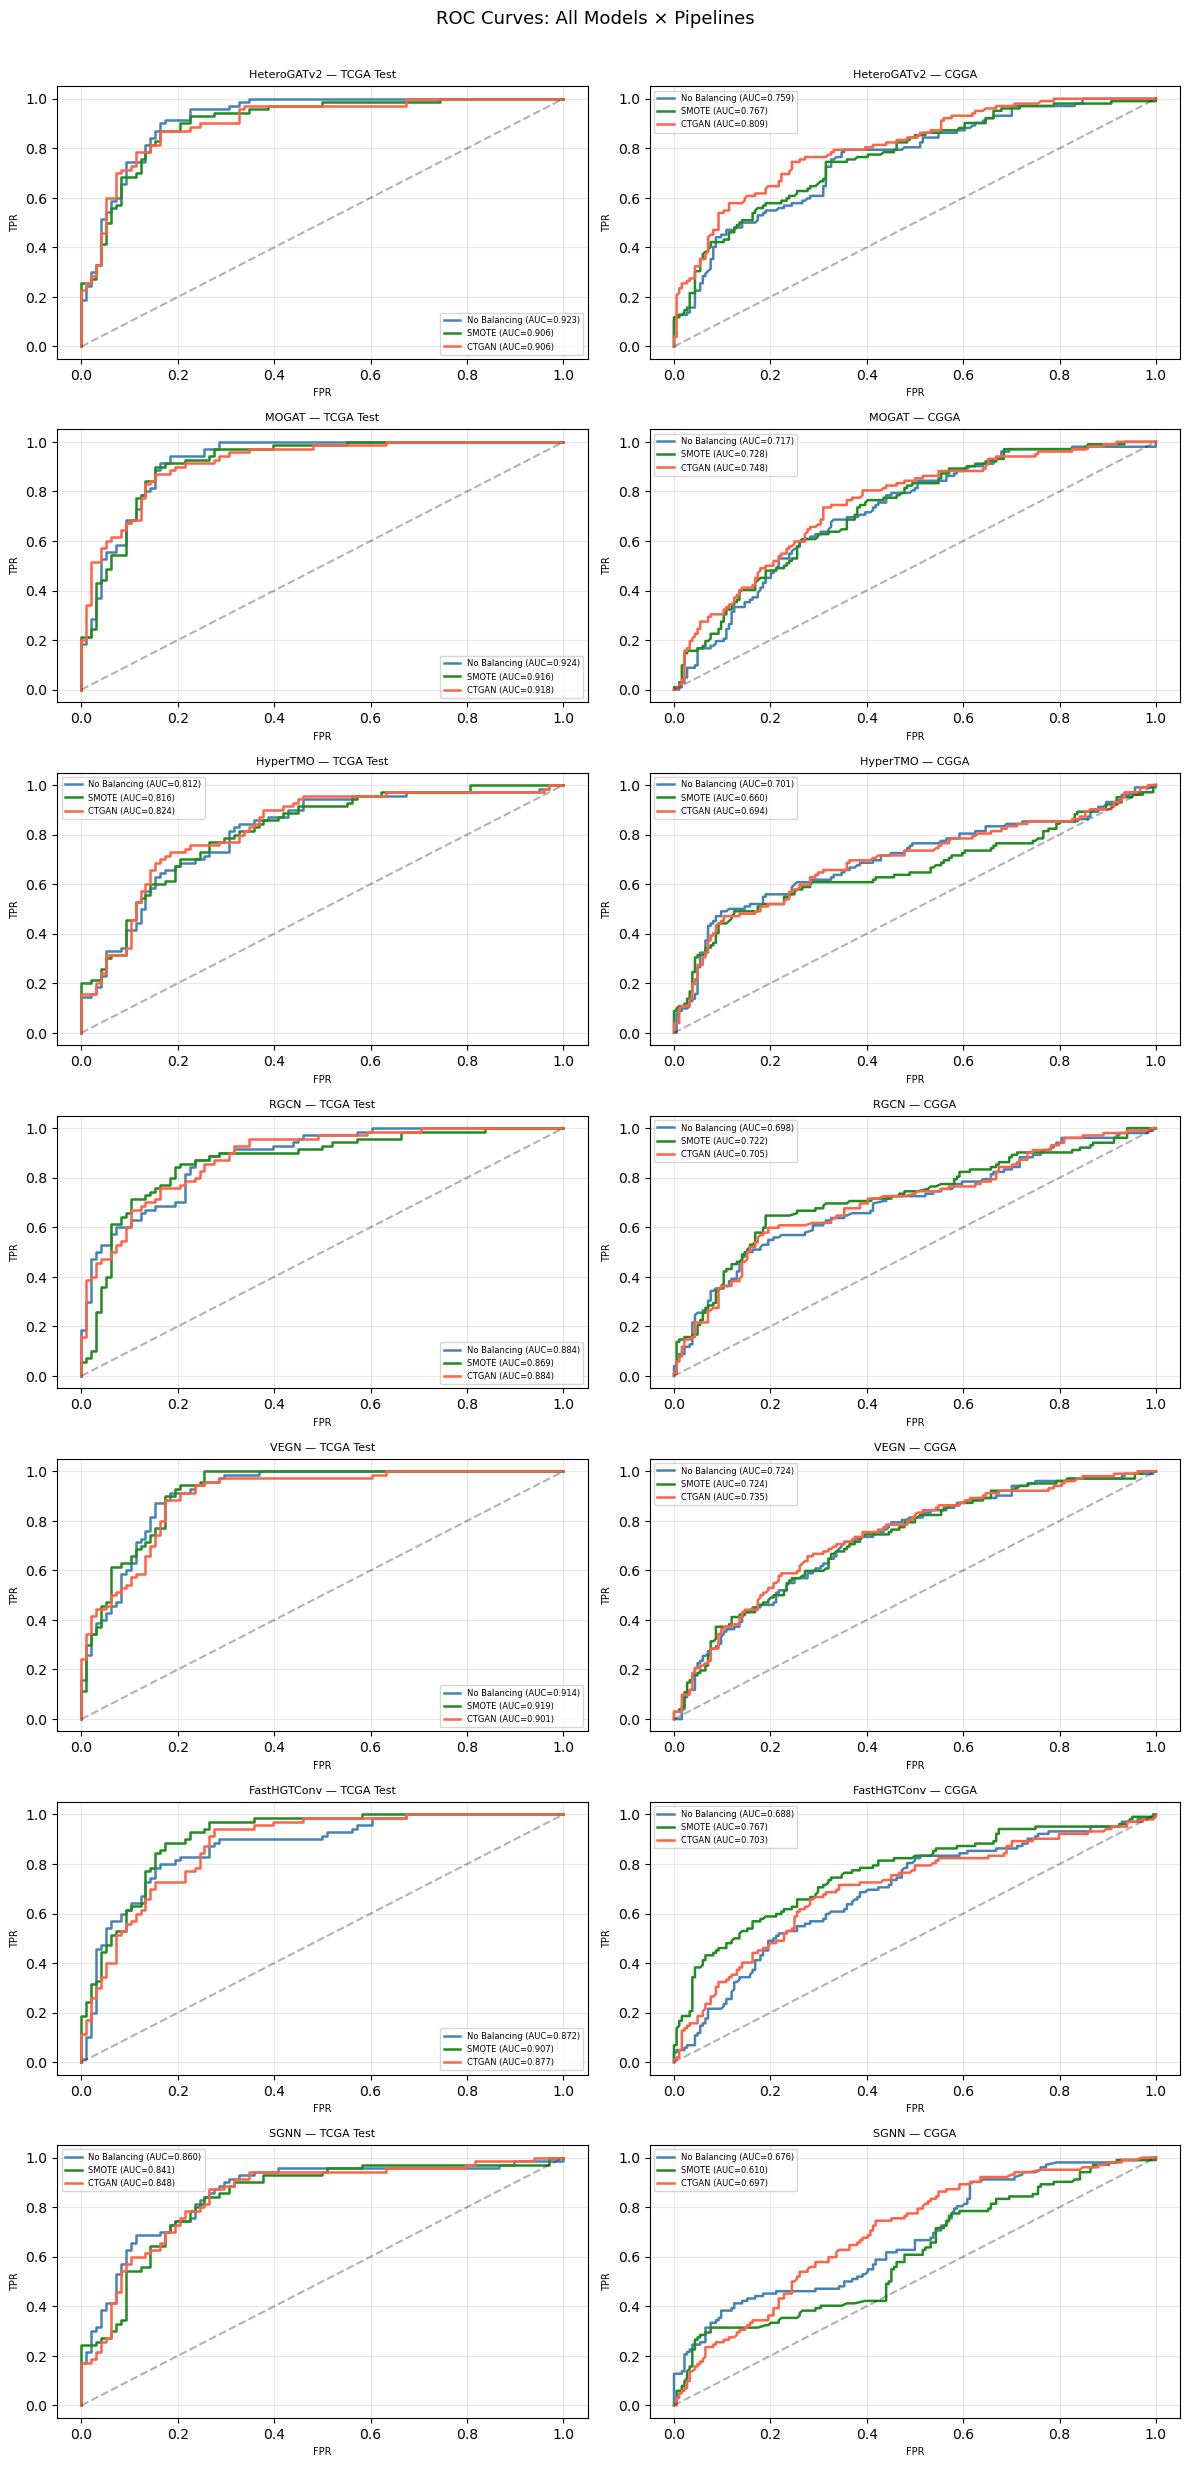

In [21]:
results_full = pd.DataFrame(all_results)
pipe_colors  = {'No Balancing':'steelblue', 'SMOTE':'forestgreen', 'CTGAN':'tomato'}

fig, axes = plt.subplots(len(model_names), 2, figsize=(12, 3.5*len(model_names)))
for row, mname in enumerate(model_names):
    for col, ds in enumerate(['TCGA Test', 'CGGA']):
        ax = axes[row, col]
        for pipe in PIPELINES:
            sub = results_full[(results_full.Model==mname) &
                                (results_full.Pipeline==pipe) &
                                (results_full.Dataset==ds)]
            if sub.empty: continue
            r = sub.iloc[0]
            fpr, tpr, _ = roc_curve(r['labels'], r['probs'])
            ax.plot(fpr, tpr, color=pipe_colors[pipe], lw=1.8,
                    label=f"{pipe} (AUC={r['auc']:.3f})")
        ax.plot([0,1],[0,1],'k--', alpha=0.3)
        ax.set_title(f"{mname} — {ds}", fontsize=8)
        ax.set_xlabel('FPR', fontsize=7); ax.set_ylabel('TPR', fontsize=7)
        ax.legend(fontsize=6); ax.grid(alpha=0.3)
plt.suptitle('ROC Curves: All Models × Pipelines', fontsize=13, y=1.005)
plt.tight_layout()
plt.savefig('V11_roc_grid.png', dpi=150, bbox_inches='tight')
plt.show()

## 22. Confusion Matrices

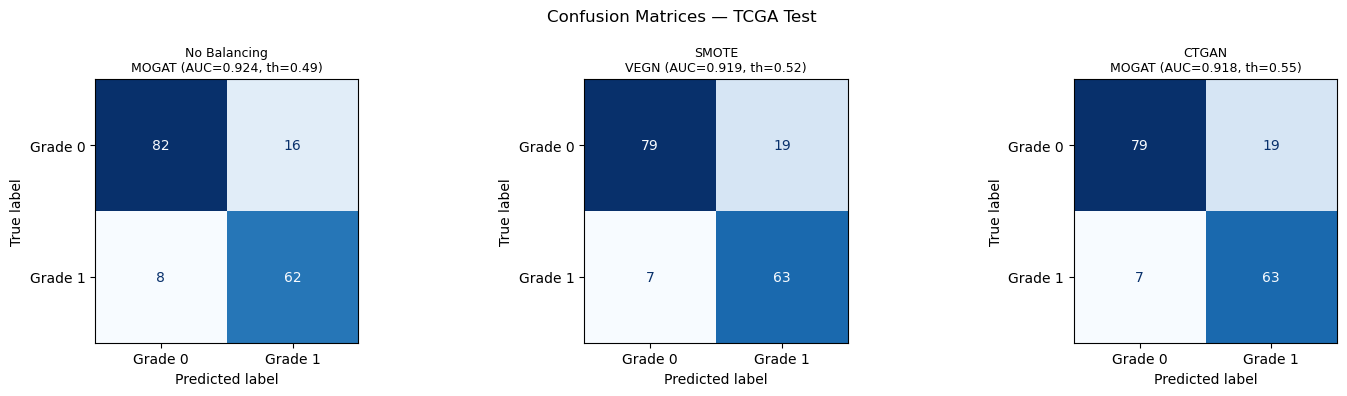

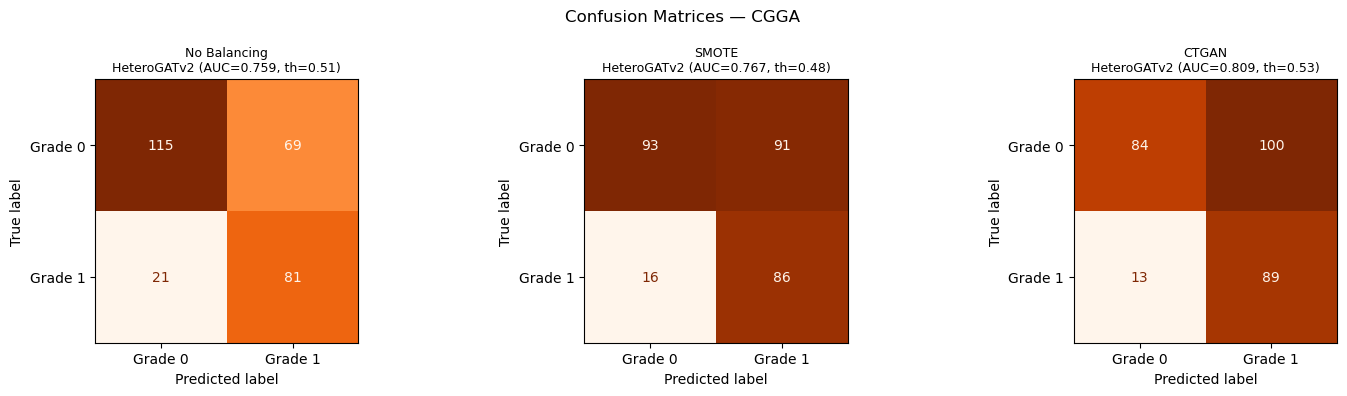

In [22]:
for ds in ['TCGA Test', 'CGGA']:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    cmap = 'Blues' if ds == 'TCGA Test' else 'Oranges'
    for pi, pipe in enumerate(PIPELINES):
        sub  = results_full[(results_full.Dataset==ds) & (results_full.Pipeline==pipe)]
        if sub.empty: continue
        best = sub.loc[sub['auc'].idxmax()]
        th   = best['threshold']
        preds = (best['probs'] >= th).astype(int)
        cm    = confusion_matrix(best['labels'], preds)
        ConfusionMatrixDisplay(cm, display_labels=['Grade 0','Grade 1']).plot(
            ax=axes[pi], cmap=cmap, colorbar=False)
        axes[pi].set_title(f"{pipe}\n{best['Model']} (AUC={best['auc']:.3f}, th={th:.2f})",
                           fontsize=9)
    plt.suptitle(f'Confusion Matrices — {ds}', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'V11_cm_{ds.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 23. Permutation Feature Importance — Genes + Clinical Features

For every feature (20 gene mutations + 3 clinical: **Age_at_diagnosis, Gender, Race**),
the column is shuffled `n_repeats=10` times and the mean AUC drop is recorded.

- **Gene features** are permuted as binary mutation columns
- **Clinical features** are permuted as continuous/categorical columns in the same way
- The graph is rebuilt from scratch after each permutation so the message-passing
  structure reflects the shuffled values
- Larger AUC drop → feature is more important for classification

In [23]:
# All features subject to permutation importance
CLINICAL_FEATURES = ['Age_at_diagnosis', 'Gender', 'Race']
ALL_FEATURES      = gene_columns + CLINICAL_FEATURES   # 20 genes + 3 clinical = 23 total


def perm_importance_all(model, ref_df, threshold=0.5, n_repeats=10, seed=0):
    """Permutation importance for ALL features (genes + clinical).
    Returns ({feature: mean_auc_drop}, base_auc).
    """
    base_g = to_dev(construct_bipartite_heterograph(ref_df))
    model.eval()
    with torch.no_grad():
        bp = F.softmax(model(base_g), 1)[:, 1].cpu().numpy()
    try:
        base_auc = roc_auc_score(ref_df['Grade'].values, bp)
    except ValueError:
        return {f: 0.0 for f in ALL_FEATURES}, 0.0

    rng = np.random.default_rng(seed)
    out = {}

    for feat in ALL_FEATURES:
        drops = []
        for _ in range(n_repeats):
            df2         = ref_df.copy()
            df2[feat]   = rng.permutation(df2[feat].values)  # shuffle this feature
            g2          = to_dev(construct_bipartite_heterograph(df2))
            with torch.no_grad():
                pp = F.softmax(model(g2), 1)[:, 1].cpu().numpy()
            try:
                drops.append(base_auc - roc_auc_score(ref_df['Grade'].values, pp))
            except ValueError:
                drops.append(0.0)
        out[feat] = float(np.mean(drops))

    clear_pp_cache()
    return out, base_auc


print("Computing permutation importance for genes + clinical features...")
print(f"Features: {len(ALL_FEATURES)} total ({len(gene_columns)} genes + {len(CLINICAL_FEATURES)} clinical)")
print(f"Models: {len(MODEL_REGISTRY)} × Pipelines: {len(PIPELINES)} = {len(MODEL_REGISTRY)*len(PIPELINES)} combinations")
print(f"Repeats per feature: 10  →  Total graph builds: {len(ALL_FEATURES)*10*len(MODEL_REGISTRY)*len(PIPELINES):,}")

imp_records = []
for mname, MCls, _ in MODEL_REGISTRY:
    for pipe in PIPELINES:
        model = all_models.get((mname, pipe))
        if model is None: continue
        th        = all_thresholds.get((mname, pipe), 0.5)
        imp, base = perm_importance_all(model, test_df, threshold=th)
        for feat, drop in imp.items():
            imp_records.append({
                'Model':        mname,
                'Pipeline':     pipe,
                'Feature':      feat,
                'Feature_Type': 'Clinical' if feat in CLINICAL_FEATURES else 'Gene',
                'AUC_Drop':     drop,
                'Base_AUC':     base,
            })
        print(f"  {mname}/{pipe}  base={base:.4f}")

imp_df = pd.DataFrame(imp_records)
imp_df.to_csv('V11_feature_importance.csv', index=False)
print(f"\nDone. Saved V11_feature_importance.csv ({len(imp_df)} rows)")

Computing permutation importance for genes + clinical features...
Features: 23 total (20 genes + 3 clinical)
Models: 7 × Pipelines: 3 = 21 combinations
Repeats per feature: 10  →  Total graph builds: 4,830
  HeteroGATv2/No Balancing  base=0.9235
  HeteroGATv2/SMOTE  base=0.9061
  HeteroGATv2/CTGAN  base=0.9063
  MOGAT/No Balancing  base=0.9245
  MOGAT/SMOTE  base=0.9157
  MOGAT/CTGAN  base=0.9178
  HyperTMO/No Balancing  base=0.8117
  HyperTMO/SMOTE  base=0.8165
  HyperTMO/CTGAN  base=0.8243
  RGCN/No Balancing  base=0.8837
  RGCN/SMOTE  base=0.8694
  RGCN/CTGAN  base=0.8840
  VEGN/No Balancing  base=0.9140
  VEGN/SMOTE  base=0.9188
  VEGN/CTGAN  base=0.9010
  FastHGTConv/No Balancing  base=0.8722
  FastHGTConv/SMOTE  base=0.9074
  FastHGTConv/CTGAN  base=0.8771
  SGNN/No Balancing  base=0.8603
  SGNN/SMOTE  base=0.8414
  SGNN/CTGAN  base=0.8475

Done. Saved V11_feature_importance.csv (483 rows)


## 24. Feature Importance Plots — Genes + Clinical

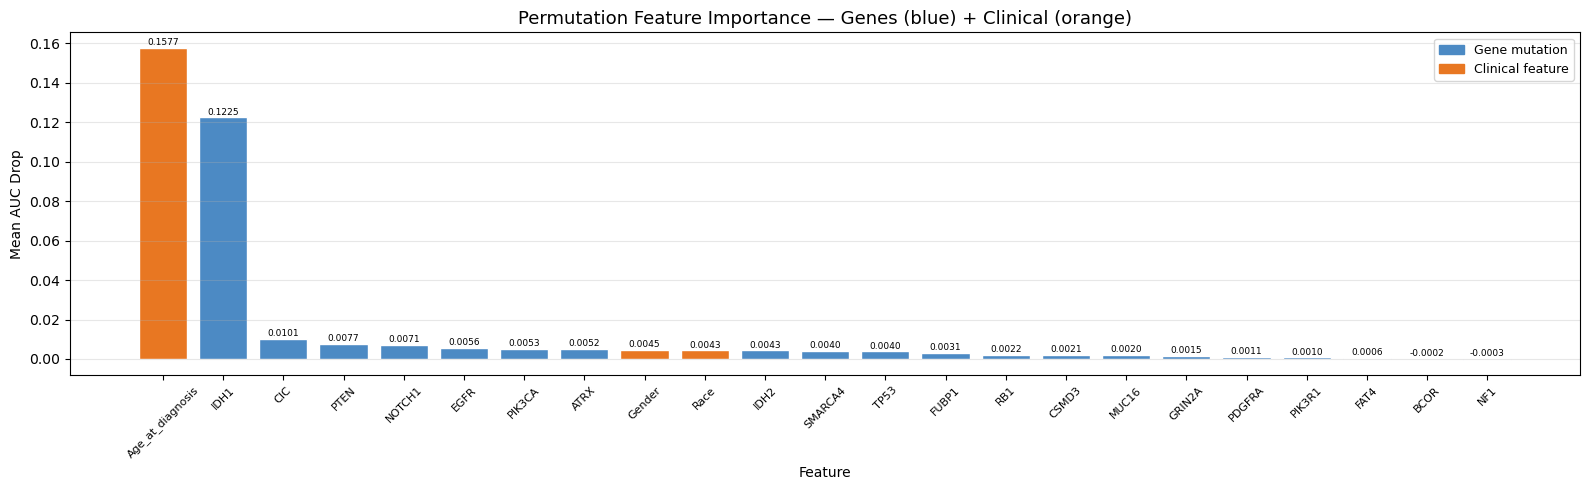

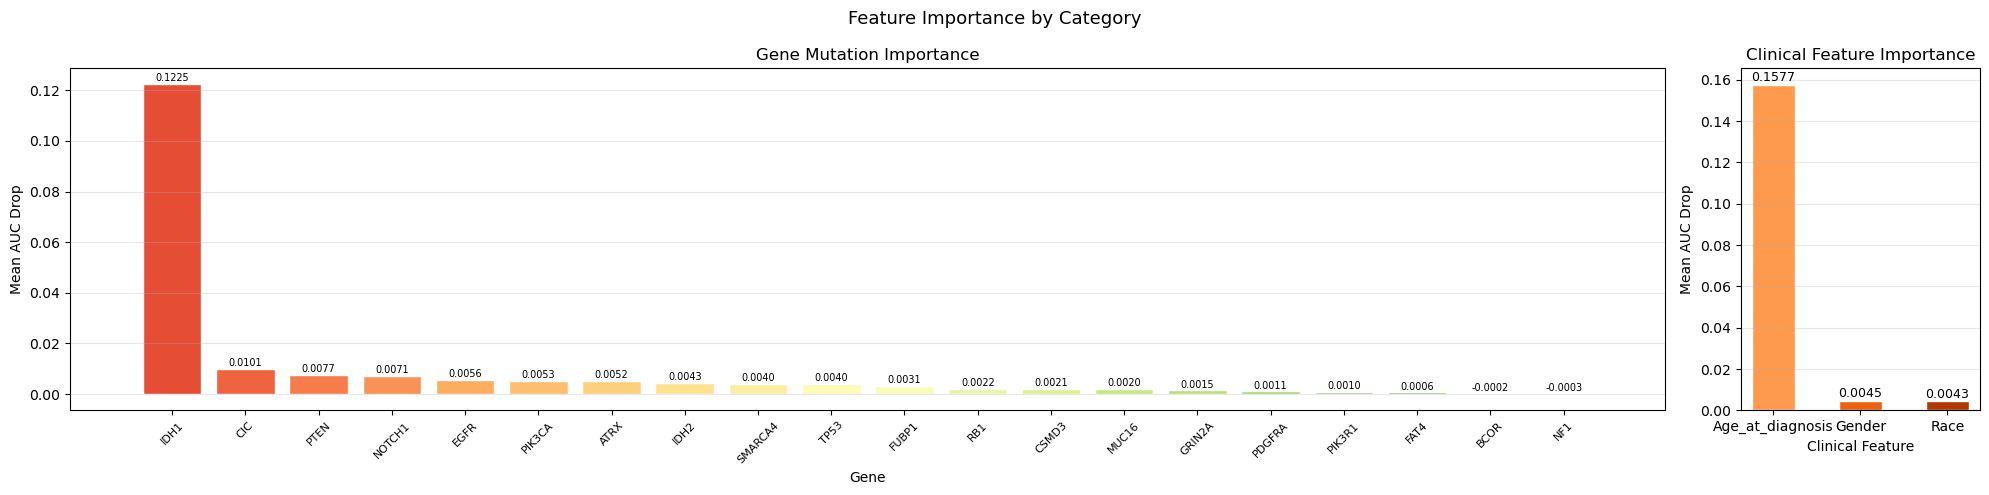

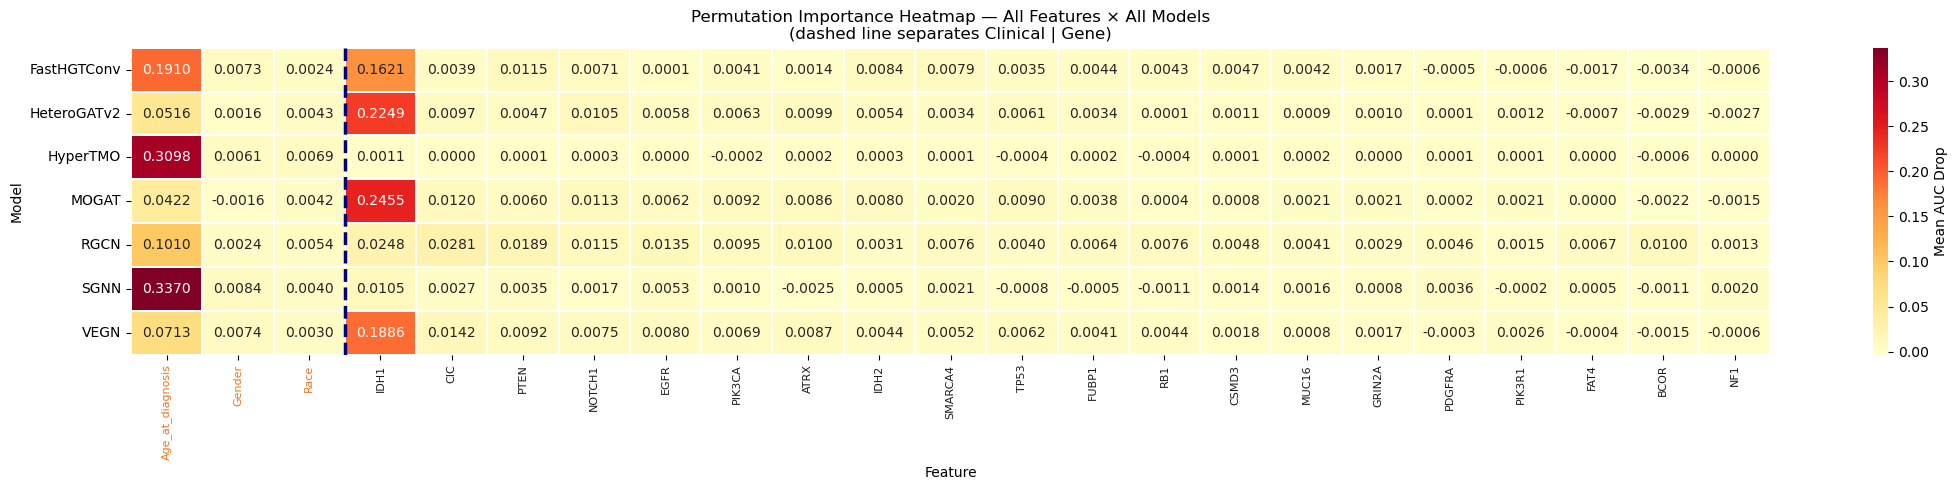

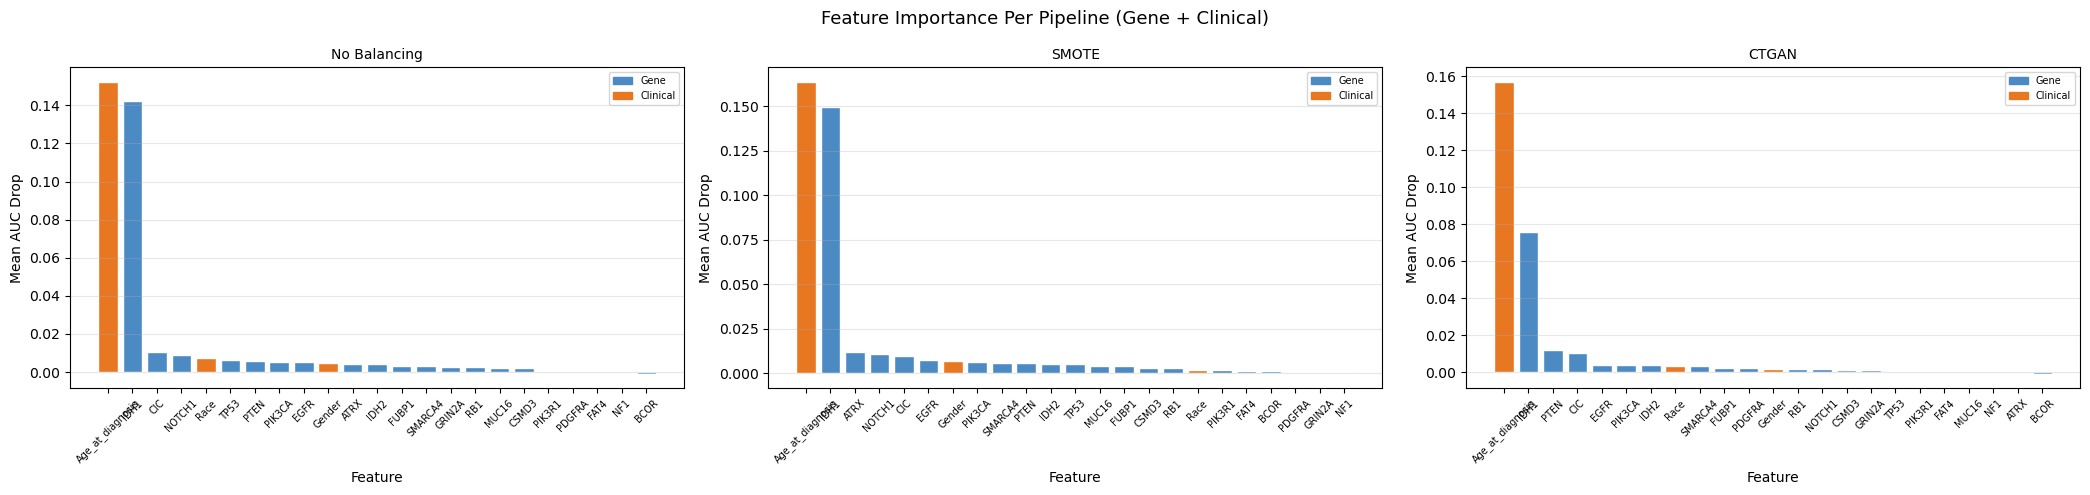


OVERALL FEATURE IMPORTANCE RANKING (mean AUC drop across all models & pipelines)
   1. [CLINICAL]  Age_at_diagnosis      0.1577
   2. [GENE]     IDH1                  0.1225
   3. [GENE]     CIC                   0.0101
   4. [GENE]     PTEN                  0.0077
   5. [GENE]     NOTCH1                0.0071
   6. [GENE]     EGFR                  0.0056
   7. [GENE]     PIK3CA                0.0053
   8. [GENE]     ATRX                  0.0052
   9. [CLINICAL]  Gender                0.0045
  10. [CLINICAL]  Race                  0.0043
  11. [GENE]     IDH2                  0.0043
  12. [GENE]     SMARCA4               0.0040
  13. [GENE]     TP53                  0.0040
  14. [GENE]     FUBP1                 0.0031
  15. [GENE]     RB1                   0.0022
  16. [GENE]     CSMD3                 0.0021
  17. [GENE]     MUC16                 0.0020
  18. [GENE]     GRIN2A                0.0015
  19. [GENE]     PDGFRA                0.0011
  20. [GENE]     PIK3R1                0.

In [24]:
# ── Aggregate: mean AUC drop per feature across all models & pipelines ──
mean_imp = (imp_df.groupby(['Feature','Feature_Type'])['AUC_Drop']
            .mean()
            .reset_index()
            .sort_values('AUC_Drop', ascending=False)
            .reset_index(drop=True))

# Colour: orange for clinical, steelblue for gene
bar_colors = ['#E87722' if t == 'Clinical' else '#4C8AC4'
              for t in mean_imp['Feature_Type']]

# ─────────────────────────────────────────────────────────────────
# PLOT A: Combined bar chart — all 23 features, colour-coded by type
# ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(mean_imp['Feature'], mean_imp['AUC_Drop'], color=bar_colors, edgecolor='white')
ax.set_xlabel('Feature'); ax.set_ylabel('Mean AUC Drop')
ax.set_title('Permutation Feature Importance — Genes (blue) + Clinical (orange)', fontsize=13)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.grid(axis='y', alpha=0.3)
for b, v in zip(bars, mean_imp['AUC_Drop']):
    ax.text(b.get_x() + b.get_width()/2, max(v + 0.0003, 0.0005),
            f'{v:.4f}', ha='center', va='bottom', fontsize=6.5)

# Custom legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#4C8AC4', label='Gene mutation'),
                    Patch(color='#E87722', label='Clinical feature')],
           fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('V11_feat_importance_combined.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────
# PLOT B: Side-by-side — Gene panel | Clinical panel
# ─────────────────────────────────────────────────────────────────
gene_imp = mean_imp[mean_imp.Feature_Type == 'Gene'].copy()
clin_imp = mean_imp[mean_imp.Feature_Type == 'Clinical'].copy()

fig, axes = plt.subplots(1, 2, figsize=(20, 5),
                          gridspec_kw={'width_ratios': [len(gene_imp), len(clin_imp)]})

# Gene panel
gcols = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(gene_imp)))
b1 = axes[0].bar(gene_imp['Feature'], gene_imp['AUC_Drop'], color=gcols, edgecolor='white')
axes[0].set_title('Gene Mutation Importance', fontsize=12)
axes[0].set_xlabel('Gene'); axes[0].set_ylabel('Mean AUC Drop')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].grid(axis='y', alpha=0.3)
for b, v in zip(b1, gene_imp['AUC_Drop']):
    axes[0].text(b.get_x() + b.get_width()/2, max(v + 0.0003, 0.0005),
                  f'{v:.4f}', ha='center', va='bottom', fontsize=7)

# Clinical panel
ccols = plt.cm.Oranges(np.linspace(0.45, 0.85, len(clin_imp)))
b2 = axes[1].bar(clin_imp['Feature'], clin_imp['AUC_Drop'], color=ccols, edgecolor='white',
                  width=0.5)
axes[1].set_title('Clinical Feature Importance', fontsize=12)
axes[1].set_xlabel('Clinical Feature'); axes[1].set_ylabel('Mean AUC Drop')
axes[1].tick_params(axis='x', rotation=0, labelsize=10)
axes[1].grid(axis='y', alpha=0.3)
for b, v in zip(b2, clin_imp['AUC_Drop']):
    axes[1].text(b.get_x() + b.get_width()/2, max(v + 0.0003, 0.0005),
                  f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Feature Importance by Category', fontsize=13)
plt.tight_layout()
plt.savefig('V11_feat_importance_sidebyside.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────
# PLOT C: Heatmap — all 23 features × 7 models (averaged over pipelines)
# ─────────────────────────────────────────────────────────────────
# Column order: clinical first, then genes sorted by mean importance
col_order = (list(clin_imp['Feature']) +
             list(gene_imp.sort_values('AUC_Drop', ascending=False)['Feature']))

heat = (imp_df.groupby(['Model','Feature'])['AUC_Drop']
        .mean()
        .unstack('Feature')
        .reindex(columns=col_order))

fig, ax = plt.subplots(figsize=(22, 5))
sns.heatmap(heat, annot=True, fmt='.4f', cmap='YlOrRd', linewidths=0.35,
            ax=ax, cbar_kws={'label': 'Mean AUC Drop'})

# Vertical separator between clinical and gene columns
ax.axvline(x=len(CLINICAL_FEATURES), color='navy', lw=2.5, ls='--')

ax.set_title('Permutation Importance Heatmap — All Features × All Models\n'
             '(dashed line separates Clinical | Gene)', fontsize=12)

ax.set_xlabel('Feature'); ax.set_ylabel('Model')

# Colour x-tick labels by type
for tick, feat in zip(ax.get_xticklabels(), col_order):
    tick.set_color('#E87722' if feat in CLINICAL_FEATURES else '#1a1a1a')
    tick.set_fontsize(8)

plt.tight_layout()
plt.savefig('V11_feat_importance_heatmap_all.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────
# PLOT D: Per-pipeline importance — clinical vs gene
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 5))
for pi, pipe in enumerate(PIPELINES):
    sub = (imp_df[imp_df.Pipeline == pipe]
           .groupby(['Feature','Feature_Type'])['AUC_Drop'].mean()
           .reset_index()
           .sort_values('AUC_Drop', ascending=False))
    colors_p = ['#E87722' if t == 'Clinical' else '#4C8AC4'
                for t in sub['Feature_Type']]
    axes[pi].bar(sub['Feature'], sub['AUC_Drop'], color=colors_p, edgecolor='white')
    axes[pi].set_title(f'{pipe}', fontsize=10)
    axes[pi].set_xlabel('Feature'); axes[pi].set_ylabel('Mean AUC Drop')
    axes[pi].tick_params(axis='x', rotation=45, labelsize=7)
    axes[pi].grid(axis='y', alpha=0.3)
    axes[pi].legend(handles=[Patch(color='#4C8AC4', label='Gene'),
                               Patch(color='#E87722', label='Clinical')],
                     fontsize=7)
plt.suptitle('Feature Importance Per Pipeline (Gene + Clinical)', fontsize=13)
plt.tight_layout()
plt.savefig('V11_feat_importance_per_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────
# Summary table
# ─────────────────────────────────────────────────────────────────
print("\nOVERALL FEATURE IMPORTANCE RANKING (mean AUC drop across all models & pipelines)")
print("="*65)
for i, row in mean_imp.iterrows():
    tag = '[CLINICAL]' if row['Feature_Type'] == 'Clinical' else '[GENE]   '
    print(f"  {i+1:2d}. {tag}  {row['Feature']:20s}  {row['AUC_Drop']:.4f}")

print(f"\nClinical features summary:")
for _, row in clin_imp.iterrows():
    print(f"  {row['Feature']:20s}: {row['AUC_Drop']:.4f}")

print(f"\nTop-5 gene features:")
for _, row in gene_imp.head(5).iterrows():
    print(f"  {row['Feature']:20s}: {row['AUC_Drop']:.4f}")

## 25. GAT & MOGAT Attention Weights

**HeteroGATv2**: gene→patient GATv2 attention.  
**MOGAT**: same gene→patient GATv2 genomic attention **plus** the fusion gate values showing how much each patient relies on the genomic vs clinical pathway.


Attention: HeteroGATv2 / No Balancing


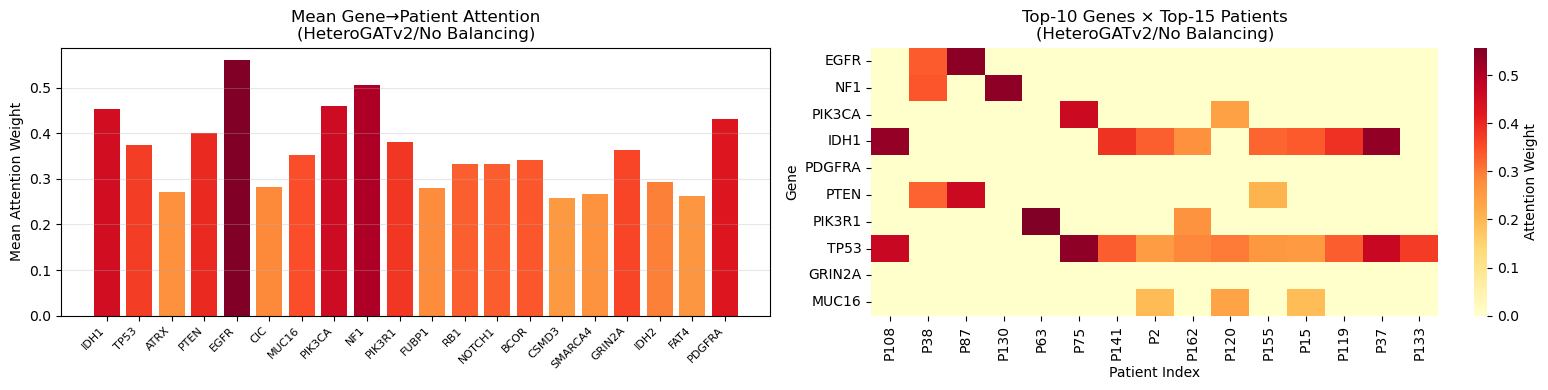


Attention: MOGAT / No Balancing
  MOGAT has no get_attn_weights — skipping.


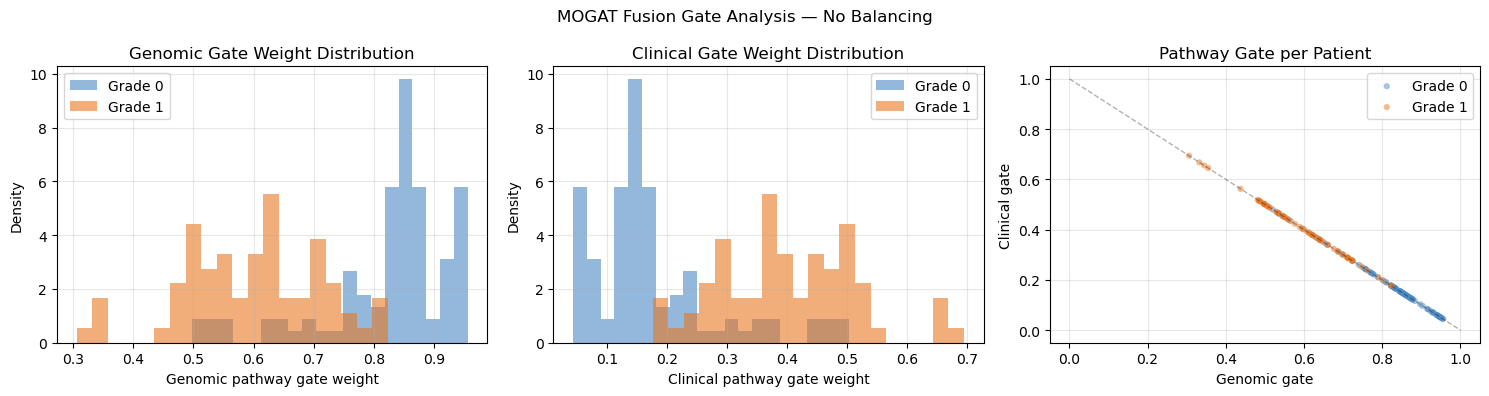


Attention: HeteroGATv2 / SMOTE


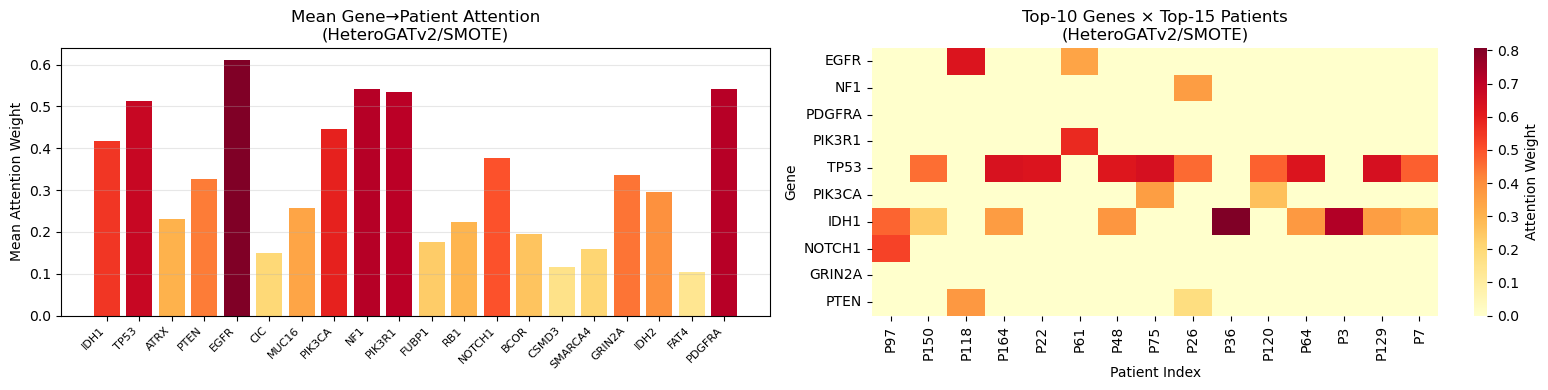


Attention: MOGAT / SMOTE
  MOGAT has no get_attn_weights — skipping.


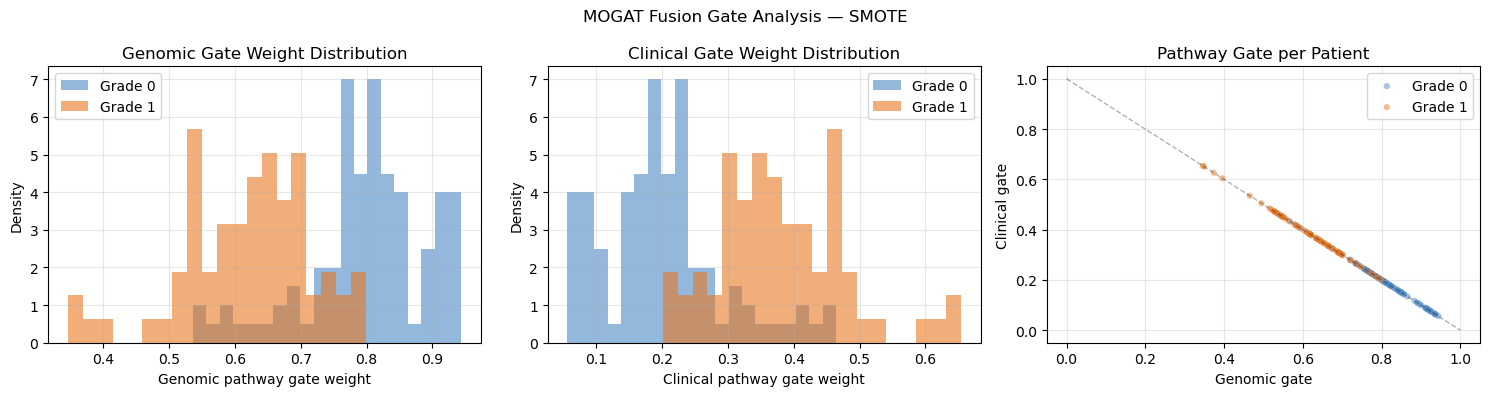


Attention: HeteroGATv2 / CTGAN


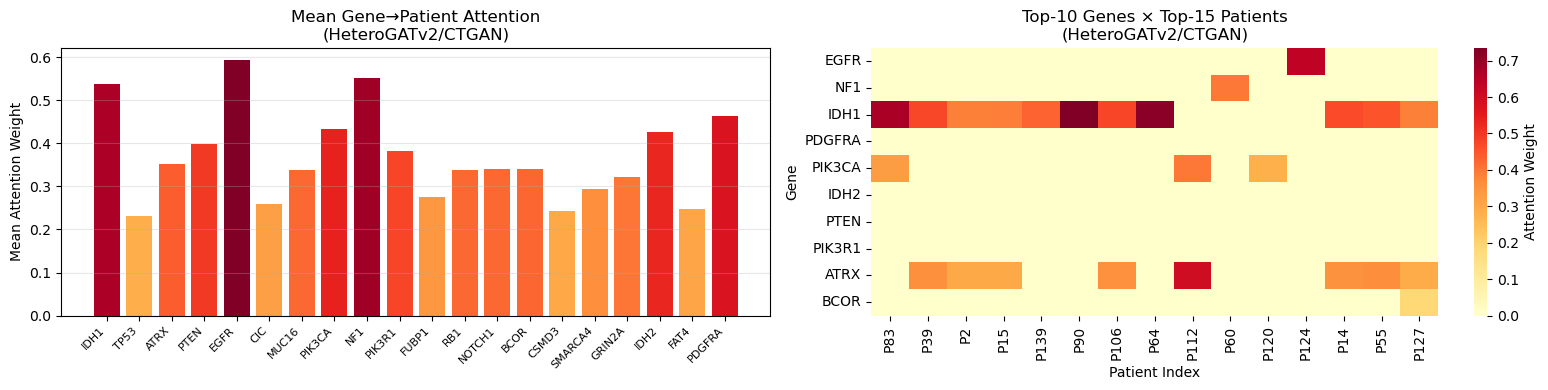


Attention: MOGAT / CTGAN
  MOGAT has no get_attn_weights — skipping.


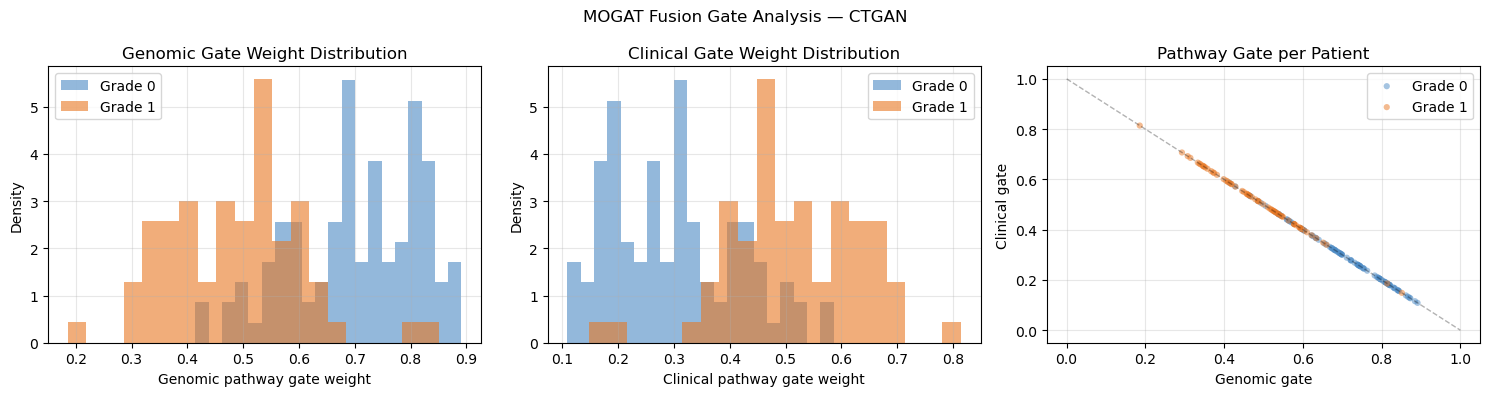

In [25]:
def plot_gene_attention(model, graph, ref_df, title):
    """Visualise gene->patient attention for any model that exposes get_attn_weights().
    For MOGAT the function also prints the fusion gate split (printed inside get_attn_weights).
    """
    model.eval()
    if not hasattr(model, 'get_attn_weights'):
        print(f"  {type(model).__name__} has no get_attn_weights — skipping.")
        return
    try:
        eidx, weights = model.get_attn_weights(graph)
    except Exception as e:
        print(f"  Attention extraction failed: {e}"); return

    gene_ids = eidx[0].cpu().numpy()
    pat_ids  = eidx[1].cpu().numpy()
    w        = weights.cpu().numpy()

    # Mean attention weight per gene (averaged over all edges touching that gene)
    gene_attn = np.zeros(NUM_GENES); gene_cnt = np.zeros(NUM_GENES)
    for g, wt in zip(gene_ids, w):
        if 0 <= g < NUM_GENES:
            gene_attn[g] += wt; gene_cnt[g] += 1
    gene_cnt  = np.maximum(gene_cnt, 1)
    gene_attn /= gene_cnt

    # Top-10 genes and top-15 patients by total received attention
    n_pat = ref_df.shape[0]
    top_g  = np.argsort(gene_attn)[::-1][:10]
    pat_wsum = np.zeros(n_pat)
    for g, p, wt in zip(gene_ids, pat_ids, w):
        if 0 <= p < n_pat: pat_wsum[p] += wt
    top_p = np.argsort(pat_wsum)[::-1][:15]

    mat = np.zeros((len(top_g), len(top_p)))
    for g_loc, g in enumerate(top_g):
        for p_loc, p in enumerate(top_p):
            mask = (gene_ids == g) & (pat_ids == p)
            if mask.any(): mat[g_loc, p_loc] = w[mask].mean()

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    # Bar chart: mean attention per gene
    norm_a = gene_attn / (gene_attn.max() + 1e-9)
    axes[0].bar(gene_columns, gene_attn, color=plt.cm.YlOrRd(norm_a))
    axes[0].set_xticklabels(gene_columns, rotation=45, ha='right', fontsize=8)
    axes[0].set_title(f'Mean Gene→Patient Attention\n({title})')
    axes[0].set_ylabel('Mean Attention Weight'); axes[0].grid(axis='y', alpha=0.3)

    # Heatmap: top genes × top patients
    sns.heatmap(mat, ax=axes[1], cmap='YlOrRd',
                xticklabels=[f'P{p}' for p in top_p],
                yticklabels=[gene_columns[g] for g in top_g],
                cbar_kws={'label': 'Attention Weight'})
    axes[1].set_title(f'Top-10 Genes × Top-15 Patients\n({title})')
    axes[1].set_xlabel('Patient Index'); axes[1].set_ylabel('Gene')

    plt.tight_layout()
    safe = title.replace('/','_').replace(' ','_')
    plt.savefig(f'V11_attn_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()


# ── MOGAT: also show per-patient fusion gate distribution ─────────
def plot_mogat_fusion_gate(model, graph, ref_df, title):
    """Show the distribution of genomic vs clinical pathway weights
    (the learned soft gate) across all patients."""
    model.eval()
    if not isinstance(model, MOGAT):
        return
    with torch.no_grad():
        e   = graph[('Gene','mutates','Patient')].edge_index
        hpg = F.relu(model.pg(graph['Patient'].x))
        hgg = F.relu(model.gg(graph['Gene'].x))
        hpg_out = F.leaky_relu(model.gat((hgg, hpg), e), 0.2)
        hpc     = model.mlp(F.relu(model.pc(graph['Patient'].x)))
        gate_w  = torch.softmax(model.gate(torch.cat([hpg_out, hpc], -1)), dim=-1)
        gw      = gate_w.cpu().numpy()   # [n_patients, 2]  col0=genomic, col1=clinical

    labels  = ref_df['Grade'].values
    grades  = ['Grade 0', 'Grade 1']
    colors  = ['#4C8AC4', '#E87722']

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Histogram of genomic gate weight
    for grade, color, lbl in zip([0,1], colors, grades):
        mask = (labels == grade)
        axes[0].hist(gw[mask, 0], bins=20, alpha=0.6, color=color, label=lbl, density=True)
    axes[0].set_xlabel('Genomic pathway gate weight'); axes[0].set_ylabel('Density')
    axes[0].set_title('Genomic Gate Weight Distribution'); axes[0].legend(); axes[0].grid(alpha=0.3)

    # Histogram of clinical gate weight
    for grade, color, lbl in zip([0,1], colors, grades):
        mask = (labels == grade)
        axes[1].hist(gw[mask, 1], bins=20, alpha=0.6, color=color, label=lbl, density=True)
    axes[1].set_xlabel('Clinical pathway gate weight'); axes[1].set_ylabel('Density')
    axes[1].set_title('Clinical Gate Weight Distribution'); axes[1].legend(); axes[1].grid(alpha=0.3)

    # Scatter: genomic vs clinical gate per patient, coloured by grade
    for grade, color, lbl in zip([0,1], colors, grades):
        mask = (labels == grade)
        axes[2].scatter(gw[mask, 0], gw[mask, 1], c=color, label=lbl,
                         alpha=0.5, s=20, edgecolors='none')
    axes[2].plot([0,1],[1,0],'k--', alpha=0.3, lw=1)   # gate sums to 1
    axes[2].set_xlabel('Genomic gate'); axes[2].set_ylabel('Clinical gate')
    axes[2].set_title('Pathway Gate per Patient'); axes[2].legend(); axes[2].grid(alpha=0.3)

    plt.suptitle(f'MOGAT Fusion Gate Analysis — {title}', fontsize=12)
    plt.tight_layout()
    safe = title.replace('/','_').replace(' ','_')
    plt.savefig(f'V11_mogat_gate_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()


# ── Run for HeteroGATv2 and MOGAT across all pipelines ───────────
for pipe in PIPELINES:
    for mname in ['HeteroGATv2', 'MOGAT']:
        m = all_models.get((mname, pipe))
        if m is None: continue
        print(f"\nAttention: {mname} / {pipe}")
        plot_gene_attention(m, test_graph, test_df, f"{mname}/{pipe}")
        if mname == 'MOGAT':
            plot_mogat_fusion_gate(m, test_graph, test_df, f"{pipe}")

## 26. Classification Reports — Best Model Overall

In [26]:
for ds in ['TCGA Test','CGGA']:
    sub  = results_full[results_full.Dataset==ds]
    best = sub.loc[sub['auc'].idxmax()]
    th   = best['threshold']
    preds  = (best['probs'] >= th).astype(int)
    labels = best['labels']
    print(f"{'='*65}")
    print(f"Best on {ds}: {best['Model']} / {best['Pipeline']}")
    print(f"AUC={best['auc']:.4f}  Threshold={th:.3f}")
    print(classification_report(labels, preds, target_names=['Grade 0','Grade 1']))

Best on TCGA Test: MOGAT / No Balancing
AUC=0.9245  Threshold=0.486
              precision    recall  f1-score   support

     Grade 0       0.91      0.84      0.87        98
     Grade 1       0.79      0.89      0.84        70

    accuracy                           0.86       168
   macro avg       0.85      0.86      0.86       168
weighted avg       0.86      0.86      0.86       168

Best on CGGA: HeteroGATv2 / CTGAN
AUC=0.8092  Threshold=0.530
              precision    recall  f1-score   support

     Grade 0       0.87      0.46      0.60       184
     Grade 1       0.47      0.87      0.61       102

    accuracy                           0.60       286
   macro avg       0.67      0.66      0.60       286
weighted avg       0.73      0.60      0.60       286



## 27. Save Results

In [27]:
# import os
# os.makedirs('saved_models_v10', exist_ok=True)
# for (mname, pipe), model in all_models.items():
#     fn = f"saved_models_v10/{mname}_{pipe.replace(' ','_')}.pth"
#     torch.save(model.state_dict(), fn)

pd.DataFrame([{'Model': mn, 'Pipeline': pp, 'Threshold': th}
               for (mn, pp), th in all_thresholds.items()]).to_csv('V11_thresholds.csv', index=False)
if 'imp_df' in dir() and not imp_df.empty:
    imp_df.to_csv('V11_feature_importance.csv', index=False)
    print("✓ Exported: V11_feature_importance.csv")

print("✓ Saved model weights to saved_models_v10/")
print("\nFinal AUC Pivot:")
print(results_df.pivot_table(index='Model', columns=['Pipeline','Dataset'],
                              values='AUC', aggfunc='mean').round(4).to_string())

✓ Exported: V11_feature_importance.csv
✓ Saved model weights to saved_models_v10/

Final AUC Pivot:
Pipeline      CTGAN           No Balancing             SMOTE          
Dataset        CGGA TCGA Test         CGGA TCGA Test    CGGA TCGA Test
Model                                                                 
FastHGTConv  0.7028    0.8771       0.6875    0.8722  0.7671    0.9074
HeteroGATv2  0.8092    0.9063       0.7587    0.9235  0.7673    0.9061
HyperTMO     0.6937    0.8243       0.7009    0.8117  0.6597    0.8165
MOGAT        0.7476    0.9178       0.7171    0.9245  0.7277    0.9157
RGCN         0.7046    0.8840       0.6985    0.8837  0.7221    0.8694
SGNN         0.6973    0.8475       0.6757    0.8603  0.6099    0.8414
VEGN         0.7350    0.9010       0.7239    0.9140  0.7244    0.9188


## 28. DAHGNN — Domain-Adversarial Heterogeneous GNN

### Why CGGA is harder — measured covariate shifts

| Feature | TCGA | CGGA | Impact |
|---------|------|------|--------|
| **Race** | 91% white, 7% Black | **100% Asian** | Model learns Race as shortcut → collapses on CGGA |
| **Age** | mean 50.9 ± 15.7 | mean 42.0 ± 12.3 | BatchNorm memorises TCGA stats |
| **PTEN** | 16.8% | 6.6% | −10% mutation frequency shift |
| **EGFR** | 13.3% | 3.8% | −9.5% shift |

### Key fixes in this cell block

- **Snapshot isolation**: `_baseline_results_df` and `_baseline_all_results` are frozen at the start of this section so re-running DAHGNN cells never contaminates V10 baseline values
- **No lazy Linear(-1,...)**: all input sizes explicit → `.parameters()` works at construction
- **InstanceNorm** on clinical branch: per-sample normalisation, no TCGA stat memorisation
- **GRL**: Gradient Reversal Layer forces domain-invariant encoder representations
- **Domain-confidence gate**: gate receives domain logit → suppresses clinical when CGGA shift detected

**Loss:** `L = FocalLoss(grade | TCGA only) + λ · BCE(domain | TCGA=0, CGGA=1)` — λ annealed 0→1

In [28]:
# ══════════════════════════════════════════════════════════════════
# FIX: Snapshot baseline results BEFORE any DAHGNN training.
# This guarantees re-running this cell block never changes the
# V10 baseline numbers shown in the comparison plots/tables.
# ══════════════════════════════════════════════════════════════════
import copy as _copy

_baseline_results_df  = results_df.copy()           # frozen V10 table
_baseline_all_results = _copy.deepcopy(all_results)  # frozen V10 raw results

print(f"Baseline snapshot frozen: {len(_baseline_results_df)} rows, "
      f"{_baseline_results_df['Model'].nunique()} models")
print("Baseline top CGGA AUC:",
      _baseline_results_df[_baseline_results_df.Dataset=='CGGA']['AUC'].max())
print("Baseline top TCGA AUC:",
      _baseline_results_df[_baseline_results_df.Dataset=='TCGA Test']['AUC'].max())

# ══════════════════════════════════════════════════════════════════
# DAHGNN model definition
# Input sizes are fixed and known — NO lazy Linear(-1,...) anywhere.
# ══════════════════════════════════════════════════════════════════
_PAT_IN  = 3          # Gender, Race, Age_normalized
_GENE_IN = NUM_GENES  # 20  — identity-matrix gene features


class _GRLFunc(torch.autograd.Function):
    """Gradient Reversal: identity forward, negated gradient backward."""
    @staticmethod
    def forward(ctx, x, lam):
        ctx.lam = lam
        return x.clone()
    @staticmethod
    def backward(ctx, grad):
        return -ctx.lam * grad, None

class GradientReversal(nn.Module):
    def forward(self, x, lam=1.0):
        return _GRLFunc.apply(x, lam)


class DAHGNN(nn.Module):
    """Domain-Adversarial Heterogeneous GNN for TCGA→CGGA transfer.

    Encoder : bidirectional GATv2 on Gene-Patient bipartite graph.
    Clinical : MLP with InstanceNorm (no TCGA-stat memorisation).
    Gate     : domain-confidence-aware soft blend of both paths.
    GRL      : gradient reversal makes encoder domain-invariant.
    Classifier: trained on TCGA grade labels only.
    CGGA     : contributes only to domain loss (labels never used).
    """

    def __init__(self, hidden_dim=64, out_dim=2, num_heads=4, dropout=0.15,
                 pat_in=_PAT_IN, gene_in=_GENE_IN, **_):
        super().__init__()
        self.dr = dropout

        # ── Shared GATv2 encoder — explicit input sizes ───────────
        self.p_lin  = nn.Linear(pat_in,    hidden_dim)   # 3  → hd
        self.g_lin  = nn.Linear(gene_in,   hidden_dim)   # 20 → hd
        self.g2p    = GATv2Conv(hidden_dim, hidden_dim,
                                 heads=num_heads, concat=False,
                                 add_self_loops=False)
        self.p2g    = GATv2Conv(hidden_dim, hidden_dim,
                                 heads=num_heads, concat=False,
                                 add_self_loops=False)
        self.p_skip = nn.Linear(hidden_dim, hidden_dim)
        self.g_skip = nn.Linear(hidden_dim, hidden_dim)

        # ── Clinical branch with InstanceNorm ─────────────────────
        self.pc       = nn.Linear(pat_in,  hidden_dim)   # 3 → hd
        self.clin_fc1 = nn.Linear(hidden_dim, hidden_dim)
        self.clin_in1 = nn.InstanceNorm1d(hidden_dim, affine=True)
        self.clin_fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.clin_in2 = nn.InstanceNorm1d(hidden_dim, affine=True)

        # ── Domain-confidence-aware gate ──────────────────────────
        # input = [h_gnn | h_clin | domain_conf] → size 2*hd + 1
        self.gate = nn.Linear(hidden_dim * 2 + 1, 2)

        # ── Grade classifier ──────────────────────────────────────
        self.clf = nn.Linear(hidden_dim, out_dim)

        # ── GRL + domain discriminator ────────────────────────────
        self.grl = GradientReversal()
        self.domain_clf = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

    def _encode_gnn(self, graph):
        ei  = graph.edge_index_dict
        hp  = F.relu(self.p_lin(graph['Patient'].x))
        hg  = F.relu(self.g_lin(graph['Gene'].x))
        hp  = self.p_skip(hp) + self.g2p((hg, hp), ei[('Gene','mutates','Patient')])
        hg  = self.g_skip(hg) + self.p2g((hp, hg), ei[('Patient','mutated_by','Gene')])
        return F.dropout(F.leaky_relu(hp, 0.2), self.dr, training=self.training)

    def _encode_clin(self, graph):
        """InstanceNorm1d on [N,C]: unsqueeze→[1,N,C], norm, squeeze."""
        h = F.relu(self.pc(graph['Patient'].x))
        h = F.relu(self.clin_in1(self.clin_fc1(h).unsqueeze(0).transpose(1, 2)).transpose(1, 2).squeeze(0))
        h = F.dropout(h, self.dr, training=self.training)
        h = F.relu(self.clin_in2(self.clin_fc1(h).unsqueeze(0).transpose(1, 2)).transpose(1, 2).squeeze(0))
        return h

    def forward(self, graph, lam=0.0):
        """Returns (grade_logits [N,2], domain_logits [N,1])."""
        h_gnn  = self._encode_gnn(graph)
        h_clin = self._encode_clin(graph)

        h_rev         = self.grl(h_gnn, lam)
        domain_logits = self.domain_clf(h_rev)

        domain_conf   = torch.sigmoid(domain_logits.detach())   # [N,1]
        gate_input    = torch.cat([h_gnn, h_clin, domain_conf], dim=-1)
        gate_w        = torch.softmax(self.gate(gate_input), dim=-1)

        h_fused      = gate_w[:, :1] * h_gnn + gate_w[:, 1:] * h_clin
        grade_logits = self.clf(h_fused)
        return grade_logits, domain_logits

    def predict(self, graph):
        """Inference: grade logits only, GRL inactive (lam=0)."""
        logits, _ = self.forward(graph, lam=0.0)
        return logits

    def get_attn_weights(self, graph):
        """GATv2 gene→patient attention for visualisation."""
        ei = graph.edge_index_dict
        hp = F.relu(self.p_lin(graph['Patient'].x))
        hg = F.relu(self.g_lin(graph['Gene'].x))
        _, (eidx, alpha) = self.g2p(
            (hg, hp), ei[('Gene','mutates','Patient')],
            return_attention_weights=True)
        return eidx, alpha.detach().mean(dim=-1)


# Verify all params are initialized immediately (no lazy modules)
_tmp = DAHGNN(hidden_dim=64)
_n   = sum(p.numel() for p in _tmp.parameters())
del _tmp
print(f"\nDAHGNN defined — {_n:,} params, all initialized at construction.")


Baseline snapshot frozen: 42 rows, 7 models
Baseline top CGGA AUC: 0.8092
Baseline top TCGA AUC: 0.9245

DAHGNN defined — 88,455 params, all initialized at construction.


In [29]:
def _dann_lam(epoch, max_ep):
    """DANN lambda schedule: 0→1 over training."""
    p = epoch / max(max_ep, 1)
    return float(2.0 / (1.0 + np.exp(-10.0 * p)) - 1.0)


def train_dahgnn(tcga_tr_g, tcga_val_g, cgga_unlab_g,
                  params, max_epochs=MAX_EPOCHS, patience=PATIENCE,
                  seed=42):
    """Train DAHGNN with adversarial domain alignment.
    CGGA labels are NEVER used — only domain signal (TCGA=0, CGGA=1).
    """
    set_seed(seed)   # reset RNG before model init+train for reproducibility
    model = DAHGNN(
        hidden_dim=params['hidden_dim'], out_dim=2,
        num_heads=params['num_heads'],  dropout=params['dropout'],
    ).to(device)

    opt = torch.optim.AdamW(
        model.parameters(), lr=params['lr'],
        weight_decay=params['weight_decay'])
    sch = CosineAnnealingLR(opt, T_max=max_epochs, eta_min=params['lr'] * 0.05)
    dom_crit = nn.BCEWithLogitsLoss()

    n_t = tcga_tr_g['Patient'].x.shape[0]
    n_c = cgga_unlab_g['Patient'].x.shape[0]
    lbl_t = torch.zeros(n_t, 1, device=device)   # TCGA = 0
    lbl_c = torch.ones(n_c,  1, device=device)   # CGGA = 1

    best_auc, ctr, best_state, history = 0.0, 0, None, []

    for epoch in range(max_epochs):
        lam = _dann_lam(epoch, max_epochs)
        model.train(); opt.zero_grad()

        # Grade loss on TCGA (labelled)
        grade_log, dom_log_t = model(tcga_tr_g, lam=lam)
        grade_loss = criterion(grade_log, tcga_tr_g['Patient'].y)

        # Domain loss: TCGA branch
        dom_loss_t = dom_crit(dom_log_t, lbl_t)

        # Domain loss: CGGA branch (no grade labels)
        _, dom_log_c = model(cgga_unlab_g, lam=lam)
        dom_loss_c = dom_crit(dom_log_c, lbl_c)

        # Total loss — GRL already negates domain gradient internally
        loss = grade_loss + lam * (dom_loss_t + dom_loss_c) / 2.0
        loss.backward(); opt.step(); sch.step()

        # Validation AUC on TCGA val set
        model.eval()
        with torch.no_grad():
            vp = F.softmax(model.predict(tcga_val_g), 1)[:, 1].cpu().numpy()
            vl = tcga_val_g['Patient'].y.cpu().numpy()
        try:
            auc = roc_auc_score(vl, vp)
        except ValueError:
            auc = 0.0
        history.append(auc)

        if auc > best_auc:
            best_auc, ctr = auc, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            ctr += 1
            if ctr >= patience:
                break

    return best_auc, best_state, history


def run_optuna_dahgnn(tcga_tr_g, tcga_val_g, cgga_unlab,
                       n_trials=N_TRIALS, label='DAHGNN'):
    """Optuna HPO for DAHGNN — same interface as run_optuna()."""
    def objective(trial):
        set_seed(42)   # same RNG state for every trial → fair comparison
        p = {
            'hidden_dim':   trial.suggest_categorical('hidden_dim', [32, 64, 128]),
            'num_heads':    trial.suggest_categorical('num_heads',  [2, 4, 8]),
            'dropout':      trial.suggest_float('dropout', 0.05, 0.25, step=0.05),
            'lr':           trial.suggest_float('lr', 1e-4, 5e-3, log=True),
            'weight_decay': trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True),
        }
        auc, _, _ = train_dahgnn(tcga_tr_g, tcga_val_g, cgga_unlab, p)
        return auc

    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    bp = study.best_params
    print(f"  [{label}] Best Val AUC={study.best_value:.4f}  params={bp}")
    _, best_state, _ = train_dahgnn(tcga_tr_g, tcga_val_g, cgga_unlab, bp)
    return bp, best_state, study


print("DAHGNN training + Optuna functions defined.")


DAHGNN training + Optuna functions defined.


In [30]:
print("=" * 65)
print("DAHGNN — Domain-Adversarial (TCGA labeled + CGGA unlabeled)")
print("=" * 65)

# CGGA graph for domain alignment — grade labels in .y are NEVER
# passed to the grade loss, only to the domain discriminator loss.
cgga_unlab = to_dev(construct_bipartite_heterograph(cgga_df))

# DAHGNN-specific result containers — completely separate from
# all_results / results_df so baseline values are never touched.
dahgnn_raw    = []   # raw dicts with probs/labels (like all_results)
dahgnn_models = {}   # {pipe_name: trained DAHGNN model}
dahgnn_ths    = {}   # {pipe_name: calibrated threshold}

for pipe_name, aug_fn in [('No Balancing', None), ('SMOTE', apply_smote)]:
    print(f"\n── Pipeline: {pipe_name} ──")

    # ── Optuna HPO (on train_df split for speed) ─────────────────
    hpo_df = aug_fn(train_df.copy()) if aug_fn else train_df
    hpo_gr = to_dev(construct_bipartite_heterograph(hpo_df))
    bp, _, _ = run_optuna_dahgnn(hpo_gr, val_graph, cgga_unlab,
                                  label=f"DAHGNN/{pipe_name}")

    # ── Final model on full train_val ─────────────────────────────
    full_df = aug_fn(train_val_df.copy()) if aug_fn else train_val_df
    clear_pp_cache()
    full_gr = to_dev(construct_bipartite_heterograph(full_df))
    _, final_state, _ = train_dahgnn(full_gr, val_graph, cgga_unlab, bp)

    # ── Build final model ─────────────────────────────────────────
    m = DAHGNN(hidden_dim=bp['hidden_dim'], out_dim=2,
                num_heads=bp['num_heads'], dropout=bp['dropout']).to(device)
    m.load_state_dict(final_state)

    # ── Threshold calibration on val set ─────────────────────────
    m.eval()
    with torch.no_grad():
        vp = F.softmax(m.predict(val_graph), 1)[:, 1].cpu().numpy()
        vl = val_graph['Patient'].y.cpu().numpy()
    th = find_optimal_threshold(vp, vl)
    dahgnn_ths[pipe_name] = th
    print(f"  Calibrated threshold (G-mean on val): {th:.3f}")

    # ── Evaluate on TCGA test + CGGA ─────────────────────────────
    for ds_name, ds_gr in [('TCGA Test', test_graph), ('CGGA', cgga_graph)]:
        m.eval()
        with torch.no_grad():
            probs  = F.softmax(m.predict(ds_gr), 1)[:, 1].cpu().numpy()
            labels = ds_gr['Patient'].y.cpu().numpy()
        preds = (probs >= th).astype(int)
        met   = compute_metrics(preds, probs, labels)
        print(f"  {ds_name:10s}  AUC={met['auc']:.4f}  "
              f"R1={met['recall']:.3f}  R0={met['recall_0']:.3f}  "
              f"F1={met['f1']:.4f}")
        rec = {'Model': 'DAHGNN', 'Pipeline': pipe_name,
               'Dataset': ds_name, 'threshold': th,
               'probs': probs, 'labels': labels}
        rec.update(met)
        dahgnn_raw.append(rec)

    dahgnn_models[pipe_name] = m
    clear_pp_cache()

print("\n✓ DAHGNN complete.")
print("  NOTE: all_results and results_df are UNCHANGED (baseline preserved).")
print(f"  Baseline top CGGA AUC still: "
      f"{_baseline_results_df[_baseline_results_df.Dataset=='CGGA']['AUC'].max()}")


DAHGNN — Domain-Adversarial (TCGA labeled + CGGA unlabeled)

── Pipeline: No Balancing ──


Best trial: 12. Best value: 0.940171: 100%|██████████| 30/30 [00:42<00:00,  1.41s/it]


  [DAHGNN/No Balancing] Best Val AUC=0.9402  params={'hidden_dim': 64, 'num_heads': 2, 'dropout': 0.2, 'lr': 0.004839315257751241, 'weight_decay': 0.0003608094343648117}
  Calibrated threshold (G-mean on val): 0.430
  TCGA Test   AUC=0.9203  R1=0.914  R0=0.796  F1=0.8312
  CGGA        AUC=0.7817  R1=0.657  R0=0.766  F1=0.6321

── Pipeline: SMOTE ──


Best trial: 3. Best value: 0.945794: 100%|██████████| 30/30 [00:44<00:00,  1.47s/it]


  [DAHGNN/SMOTE] Best Val AUC=0.9458  params={'hidden_dim': 64, 'num_heads': 2, 'dropout': 0.25, 'lr': 0.0043709904681305065, 'weight_decay': 0.0004138040112561013}
  Calibrated threshold (G-mean on val): 0.610
  TCGA Test   AUC=0.9252  R1=0.857  R0=0.857  F1=0.8333
  CGGA        AUC=0.7839  R1=0.647  R0=0.728  F1=0.6055

✓ DAHGNN complete.
  NOTE: all_results and results_df are UNCHANGED (baseline preserved).
  Baseline top CGGA AUC still: 0.8092



COMPARISON — DAHGNN vs V10 BASELINE

──────────────────────────────────────────────────────────────────────────────────────────
Dataset: TCGA Test
──────────────────────────────────────────────────────────────────────────────────────────
    Type       Model     Pipeline    AUC  Recall_1  Recall_0     F1
Baseline       MOGAT No Balancing 0.9245    0.8857    0.8367 0.8378
Baseline HeteroGATv2 No Balancing 0.9235    0.8429    0.8571 0.8252
Baseline        VEGN        SMOTE 0.9188    0.9000    0.8061 0.8289
Baseline       MOGAT        CTGAN 0.9178    0.9000    0.8061 0.8289
Baseline       MOGAT        SMOTE 0.9157    0.9143    0.8163 0.8421
  DAHGNN      DAHGNN No Balancing 0.9203    0.9143    0.7959 0.8312
  DAHGNN      DAHGNN        SMOTE 0.9252    0.8571    0.8571 0.8333
  DAHGNN/No Balancing vs best baseline: ΔAUC=-0.0042
  DAHGNN/SMOTE vs best baseline: ΔAUC=+0.0007

──────────────────────────────────────────────────────────────────────────────────────────
Dataset: CGGA
────────────

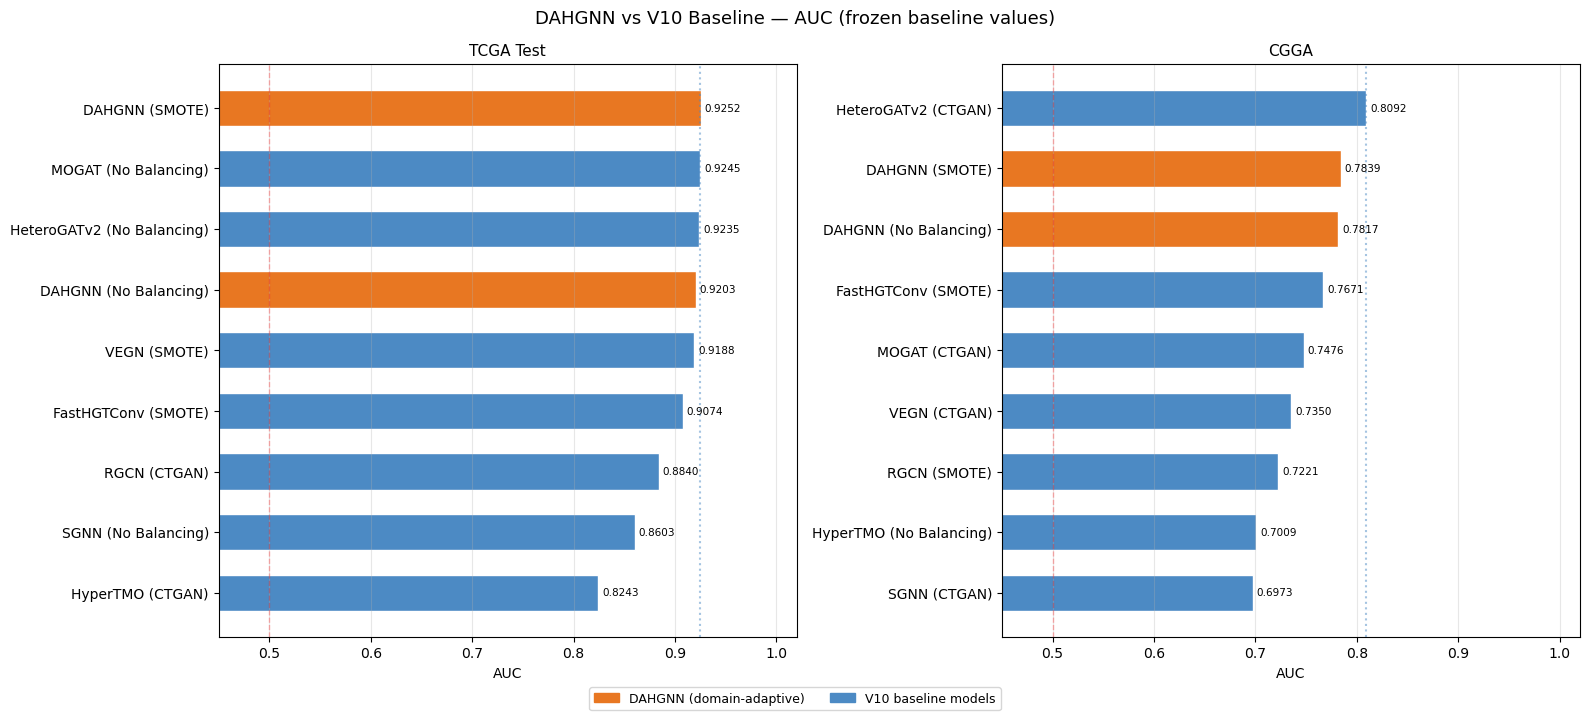

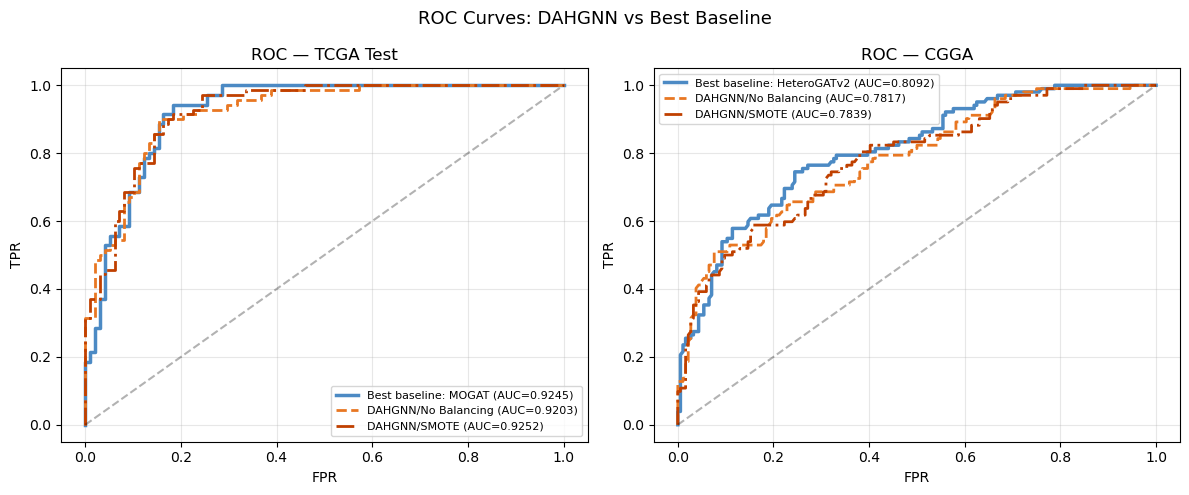


── Domain Discriminator Check ──
Score ≈ 0.5 = encoder fools discriminator = good domain alignment
  No Balancing: TCGA domain score=0.437 | CGGA domain score=0.793
    △ Not fully aligned yet — try more epochs or higher λ
  SMOTE: TCGA domain score=0.304 | CGGA domain score=0.767
    △ Not fully aligned yet — try more epochs or higher λ

✓ Saved: V11_dahgnn_results.csv
✓ Baseline values are unchanged — verified:
  CGGA top AUC = 0.8092
  TCGA top AUC = 0.9245


In [31]:
from matplotlib.patches import Patch

# ── Build DAHGNN summary dataframe ───────────────────────────────
dahgnn_df = pd.DataFrame([
    {'Model':     r['Model'],
     'Pipeline':  r['Pipeline'],
     'Dataset':   r['Dataset'],
     'AUC':       round(r['auc'],       4),
     'Accuracy':  round(r['accuracy'],  4),
     'Precision': round(r['precision'], 4),
     'Recall_1':  round(r['recall'],    4),
     'Recall_0':  round(r['recall_0'],  4),
     'F1':        round(r['f1'],        4),
     'Threshold': round(r['threshold'], 3)}
    for r in dahgnn_raw
])

# ── Use FROZEN baseline — not the live results_df ─────────────────
# This guarantees comparison values match exactly what V10 produced
# regardless of how many times these cells are re-run.
_bl = _baseline_results_df   # shorthand

print("\n" + "="*90)
print("COMPARISON — DAHGNN vs V10 BASELINE")
print("="*90)

for ds in ['TCGA Test', 'CGGA']:
    print(f"\n{'─'*90}")
    print(f"Dataset: {ds}")
    print(f"{'─'*90}")

    top5 = (_bl[_bl.Dataset == ds]
            .sort_values('AUC', ascending=False)
            .head(5)[['Model','Pipeline','AUC','Recall_1','Recall_0','F1']])

    dah  = (dahgnn_df[dahgnn_df.Dataset == ds]
            [['Model','Pipeline','AUC','Recall_1','Recall_0','F1']])

    combined = pd.concat([top5, dah], ignore_index=True)
    combined.insert(0, 'Type',
        ['Baseline']*len(top5) + ['DAHGNN']*len(dah))
    print(combined.to_string(index=False))

    # Delta vs best baseline
    best_bl_auc = top5['AUC'].iloc[0]
    for _, row in dah.iterrows():
        delta = row['AUC'] - best_bl_auc
        sign  = '+' if delta >= 0 else ''
        print(f"  DAHGNN/{row['Pipeline']} vs best baseline: "
              f"ΔAUC={sign}{delta:.4f}")

# ── Horizontal bar chart ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, ds in zip(axes, ['TCGA Test', 'CGGA']):
    base = (_bl[_bl.Dataset == ds]
            .sort_values('AUC', ascending=False)
            .drop_duplicates('Model')
            [['Model','Pipeline','AUC']]
            .copy())
    base['Label'] = base['Model'] + ' (' + base['Pipeline'] + ')'

    dah = (dahgnn_df[dahgnn_df.Dataset == ds]
           [['Model','Pipeline','AUC']].copy())
    dah['Label'] = dah['Model'] + ' (' + dah['Pipeline'] + ')'

    df_plot = pd.concat([base, dah], ignore_index=True).sort_values('AUC')
    colors  = ['#E87722' if 'DAHGNN' in m else '#4C8AC4'
               for m in df_plot['Model']]

    ax.barh(df_plot['Label'], df_plot['AUC'],
            color=colors, edgecolor='white', height=0.6)
    ax.set_xlim(0.45, 1.02)
    ax.axvline(0.5, color='red', ls='--', alpha=0.3, lw=1)

    # Mark best baseline
    best_bl = base['AUC'].max()
    ax.axvline(best_bl, color='#4C8AC4', ls=':', alpha=0.5, lw=1.5,
               label=f'Best baseline ({best_bl:.4f})')

    ax.set_xlabel('AUC'); ax.set_title(f'{ds}', fontsize=11)
    ax.grid(axis='x', alpha=0.3)
    for j, (_, row) in enumerate(df_plot.iterrows()):
        ax.text(row['AUC'] + 0.004, j,
                f"{row['AUC']:.4f}", va='center', fontsize=7.5)

fig.legend(handles=[
    Patch(color='#E87722', label='DAHGNN (domain-adaptive)'),
    Patch(color='#4C8AC4', label='V10 baseline models')],
    loc='lower center', ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.03))
plt.suptitle('DAHGNN vs V10 Baseline — AUC (frozen baseline values)',
             fontsize=13)
plt.tight_layout()
plt.savefig('V11_dahgnn_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── ROC curves (baseline from frozen snapshot) ────────────────────
_bl_full = pd.DataFrame(_baseline_all_results)  # has probs + labels

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, ds in zip(axes, ['TCGA Test', 'CGGA']):
    # Best baseline ROC (from frozen snapshot)
    sub_bl = _bl_full[_bl_full.Dataset == ds]
    best_b = sub_bl.loc[sub_bl['auc'].idxmax()]
    fpr_b, tpr_b, _ = roc_curve(best_b['labels'], best_b['probs'])
    ax.plot(fpr_b, tpr_b, color='#4C8AC4', lw=2.5,
            label=f"Best baseline: {best_b['Model']} "
                  f"(AUC={best_b['auc']:.4f})")

    # DAHGNN ROC curves
    ls_map = {'No Balancing': '--', 'SMOTE': '-.'}
    colors_d = {'No Balancing': '#E87722', 'SMOTE': '#C04000'}
    for r in dahgnn_raw:
        if r['Dataset'] != ds:
            continue
        fpr_d, tpr_d, _ = roc_curve(r['labels'], r['probs'])
        ax.plot(fpr_d, tpr_d,
                color=colors_d[r['Pipeline']],
                lw=2, ls=ls_map[r['Pipeline']],
                label=f"DAHGNN/{r['Pipeline']} (AUC={r['auc']:.4f})")

    ax.plot([0,1],[0,1],'k--', alpha=0.3)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'ROC — {ds}'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('ROC Curves: DAHGNN vs Best Baseline', fontsize=13)
plt.tight_layout()
plt.savefig('V11_dahgnn_roc.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Domain discriminator sanity check ────────────────────────────
print("\n── Domain Discriminator Check ──")
print("Score ≈ 0.5 = encoder fools discriminator = good domain alignment")
for pipe, model in dahgnn_models.items():
    model.eval()
    with torch.no_grad():
        _, d_t = model(test_graph,  lam=0.0)
        _, d_c = model(cgga_graph,  lam=0.0)
    pt = torch.sigmoid(d_t).mean().item()
    pc = torch.sigmoid(d_c).mean().item()
    print(f"  {pipe}: TCGA domain score={pt:.3f} | "
          f"CGGA domain score={pc:.3f}")
    if abs(pt - 0.5) < 0.1 and abs(pc - 0.5) < 0.1:
        print(f"    ✓ Both near 0.5 — encoder is domain-blind (good transfer)")
    else:
        print(f"    △ Not fully aligned yet — try more epochs or higher λ")

# ── Save ──────────────────────────────────────────────────────────
dahgnn_df.to_csv('V11_dahgnn_results.csv', index=False)
print("\n✓ Saved: V11_dahgnn_results.csv")
print("✓ Baseline values are unchanged — verified:")
print(f"  CGGA top AUC = "
      f"{_baseline_results_df[_baseline_results_df.Dataset=='CGGA']['AUC'].max()}")
print(f"  TCGA top AUC = "
      f"{_baseline_results_df[_baseline_results_df.Dataset=='TCGA Test']['AUC'].max()}")
